# **Importing Data** & **Libraries**

In [4]:
pip install kaleido==0.2.1

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.multiclass import OneVsRestClassifier
from imblearn.over_sampling import SMOTENC
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
from itertools import cycle
import warnings
warnings.filterwarnings('ignore')

In [6]:
import plotly.io as pio
import plotly.express as px

# Set the default renderer to png for all subsequent plots
pio.renderers.default = "png"

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
train_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Data Analysis Project - Group 7/train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Data Analysis Project - Group 7/test.csv")

In [8]:
# Categorical Variables (qualitative / text-based or group identifiers) in cleanened dataset
cats = ['Year', 'Month', 'DayPeriod', 'Type', 'Operator', 'LocationType', 'Continent', 'Country', 'WaterBodyType', 'WaterBodyName',
        'FederalSubject', 'CauseCategory', 'WeatherCondition', 'FlightPhase', 'SurvivalSeverity']

# Quantitative Variables (numeric and measurable) in cleanened dataset
quants = ['Aboard', 'Fatalities', 'Ground']

# **Approach 1**: Using the **Initial Predictors**

**Part 1.1**: Applying **SMOTENC** (Synthetic Minority Over-sampling Technique for Nominal and Continuous)

In [9]:
from imblearn.over_sampling import SMOTENC
from sklearn.model_selection import train_test_split

# Define categorical and quantitative columns (excluding the target)
categorical_cols = [col for col in cats if col != 'SurvivalSeverity']
quantitative_cols = quants

# Define categorical feature indices (based on encoded DataFrame)
X = train_df.drop(columns=['SurvivalSeverity'])  # predictors
y = train_df['SurvivalSeverity']                 # response

# Get column indices of categorical columns in X
categorical_indices = [X.columns.get_loc(col) for col in categorical_cols]

# Convert X to numpy if not already
X_np = X.values

# Apply SMOTENC
smote_nc = SMOTENC(categorical_features=categorical_indices, random_state=42)
X_resampled, y_resampled = smote_nc.fit_resample(X_np, y)

# Optionally convert back to DataFrame
X_resampled_df = pd.DataFrame(X_resampled, columns=X.columns)
y_resampled_df = pd.Series(y_resampled, name='SurvivalSeverity')

* Check the distribution of **SurvivalSeverity** after applying SMOTENC

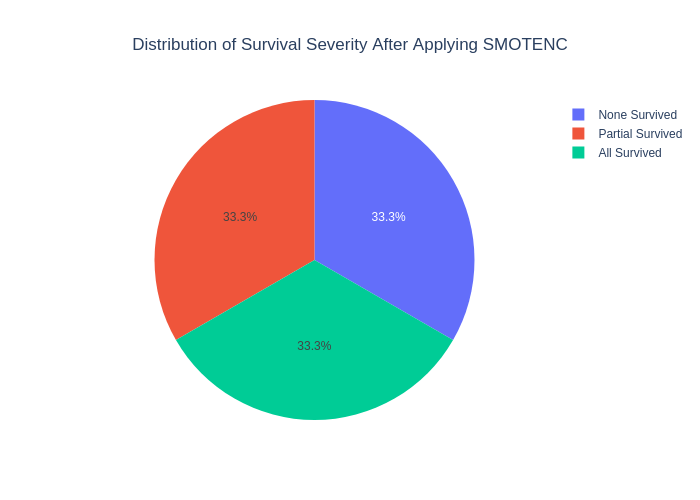

In [10]:
# Counts
severityCounts = y_resampled_df.value_counts().reset_index()
severityCounts.columns = ['SurvivalSeverity', 'Count']

# Plot
fig14 = px.pie(
    severityCounts,
    names='SurvivalSeverity',
    values='Count',
    title='Distribution of Survival Severity After Applying SMOTENC',
    labels={'SurvivalSeverity': 'Survival Severity', 'Count': 'No. of Crashes'}
)

fig14.update_layout(
    title_x=0.5
)

fig14.show()

In [11]:
X_train = X_resampled_df
y_train = y_resampled_df

X_test = test_df.drop(columns=['SurvivalSeverity'])
y_test = test_df['SurvivalSeverity']

**Part 1.2**: Training Classification Models

*   **Baseline Model**: Multivariate Logistic Regression
*   **Tree Based Models**: Classification Trees, Random Forest, XGBoost

Starting hyperparameter tuning...

Training Logistic Regression...
Best parameters: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV score: 0.8940

Training Decision Tree...
Best parameters: {'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best CV score: 0.9432

Training Random Forest...
Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
Best CV score: 0.8944

Training XGBoost...
Best parameters: {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200, 'subsample': 1.0}
Best CV score: 0.9606

Hyperparameter tuning completed!

Generating plots for Logistic Regression...


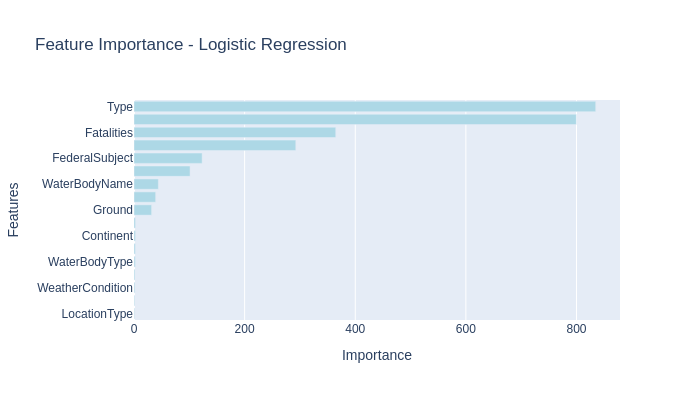

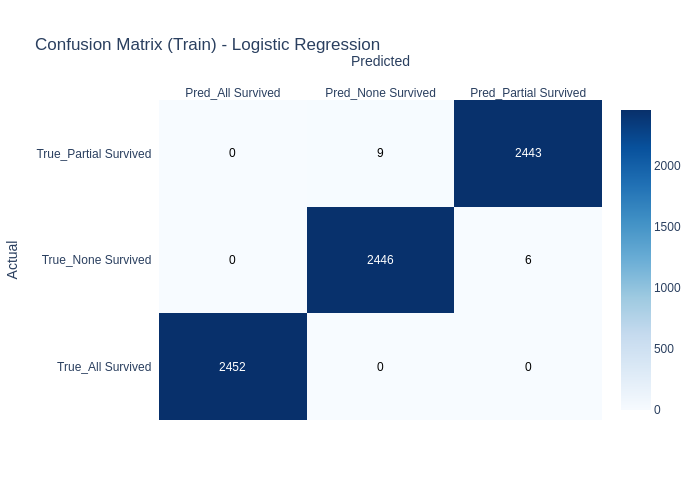

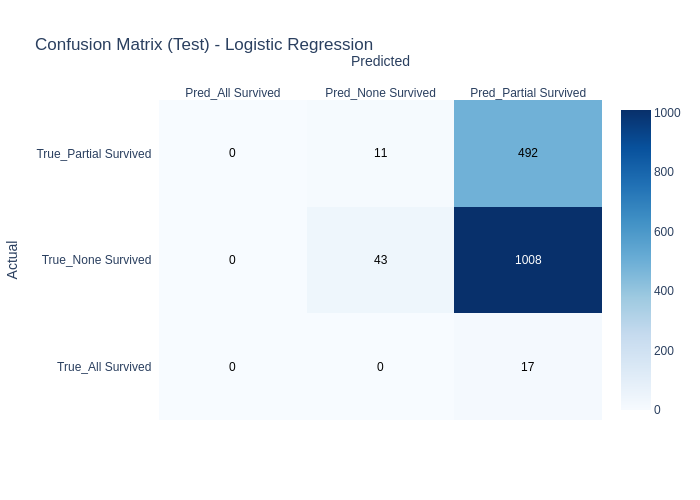

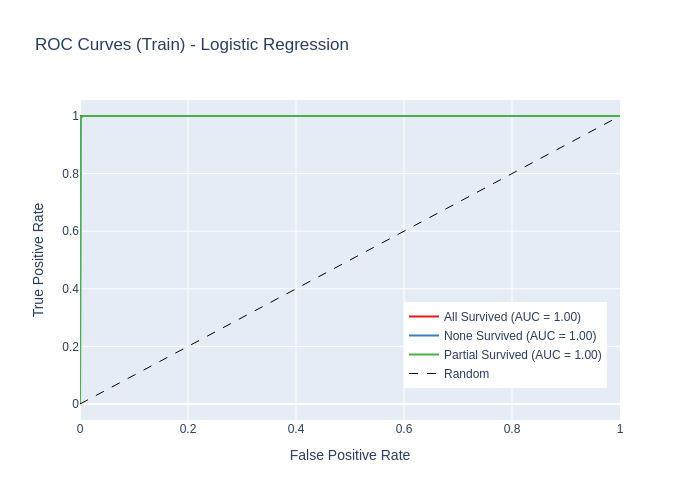

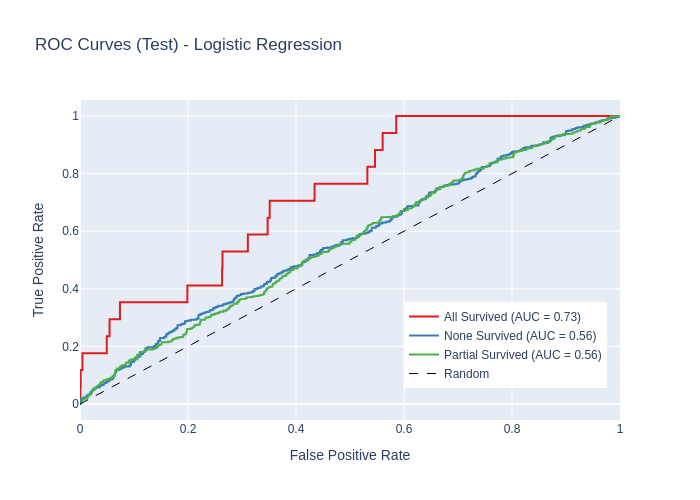


Generating plots for Decision Tree...


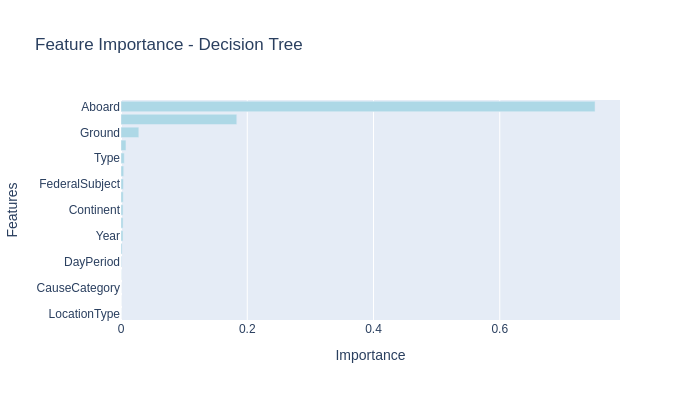

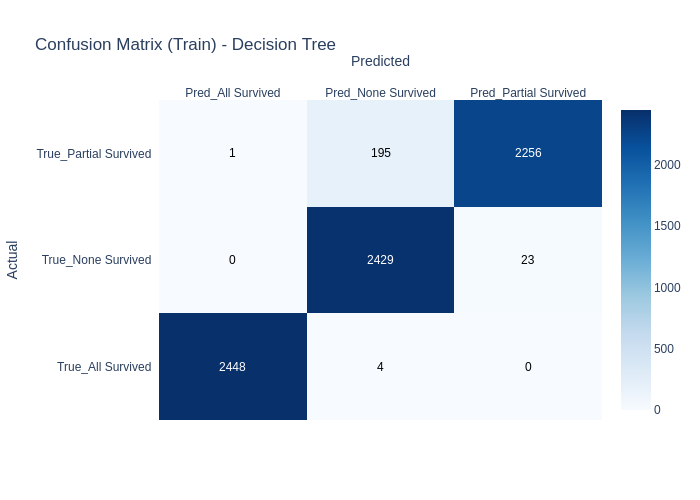

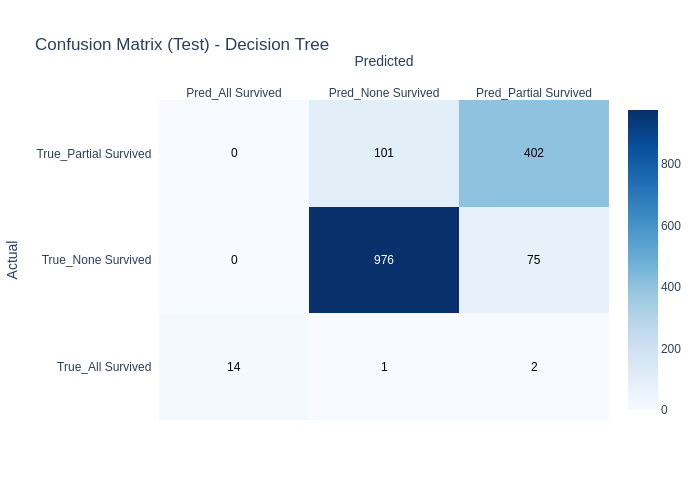

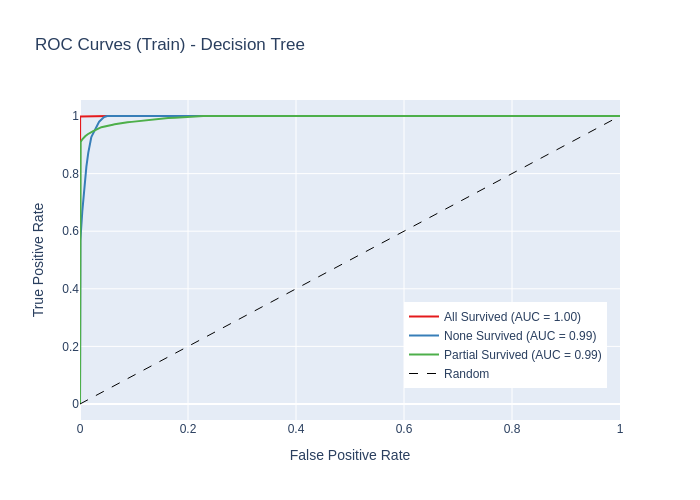

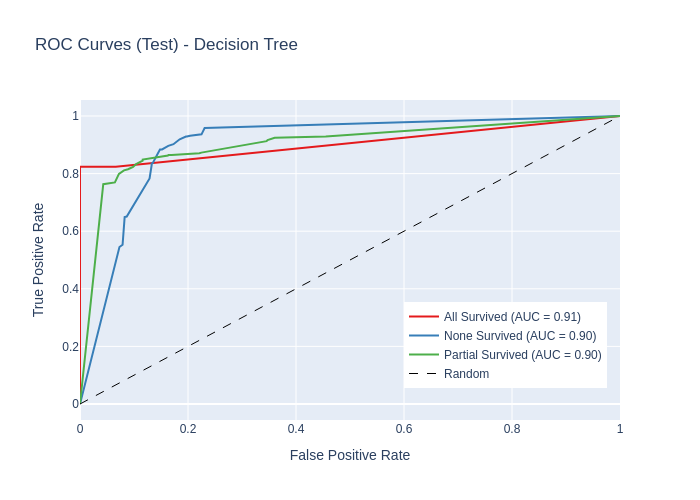


Generating plots for Random Forest...


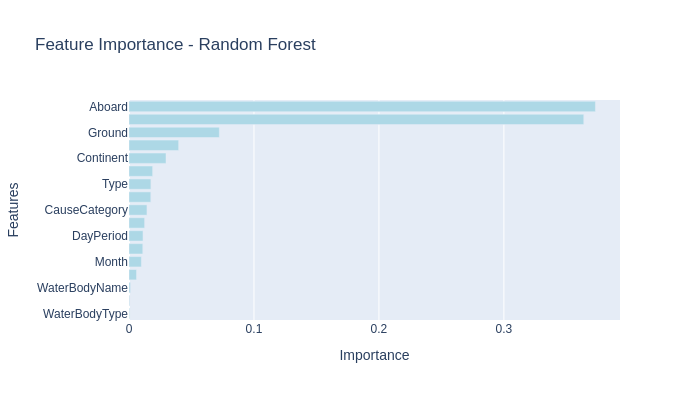

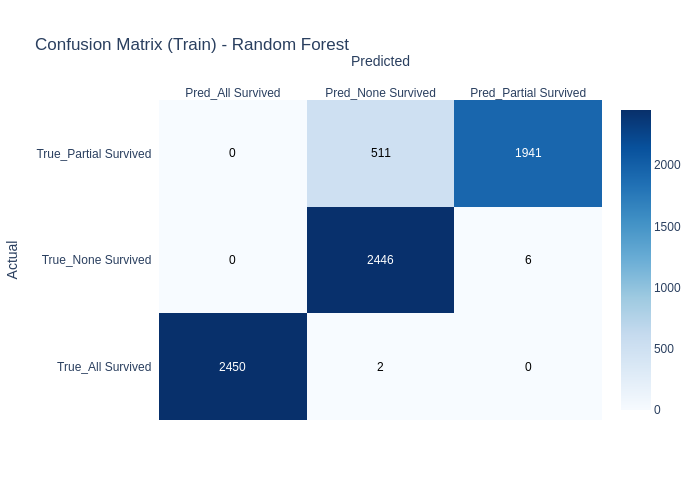

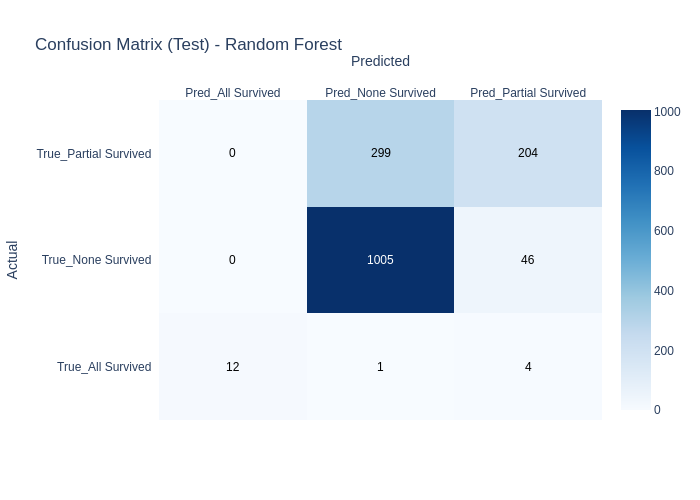

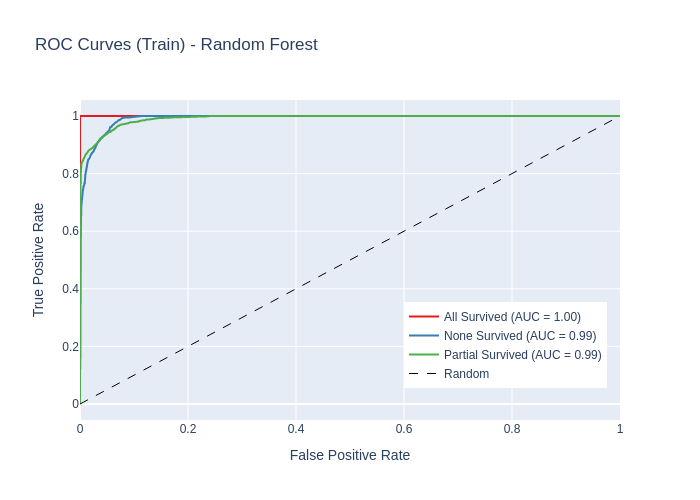

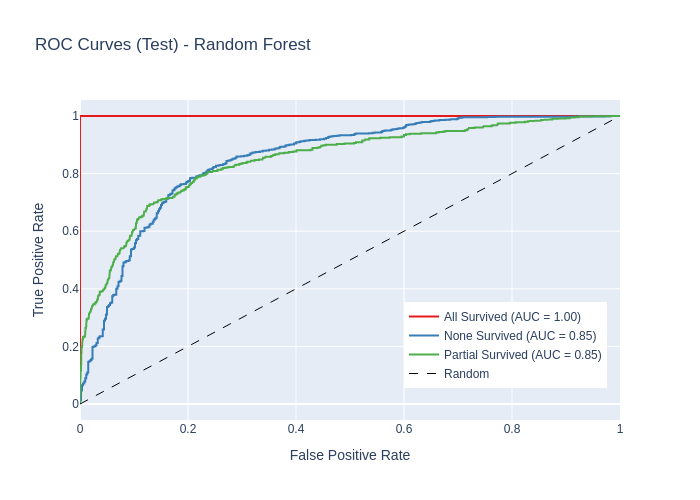


Generating plots for XGBoost...


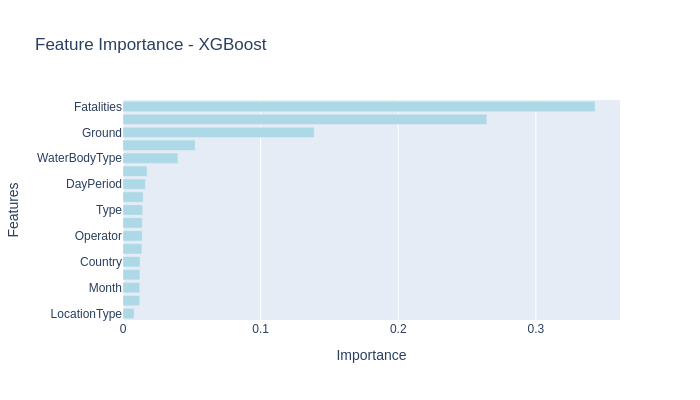

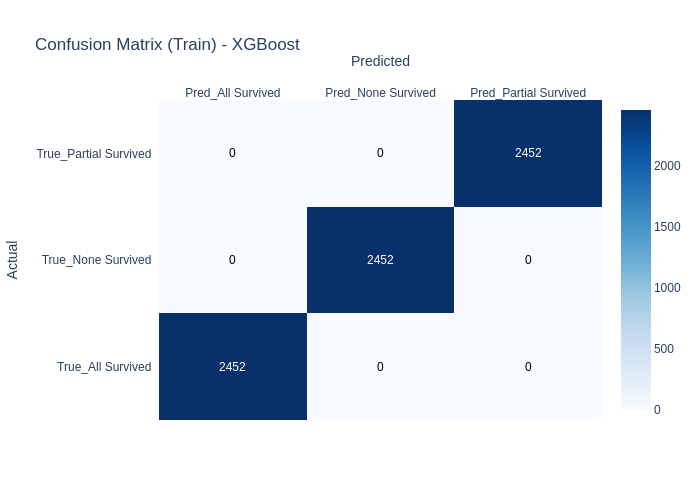

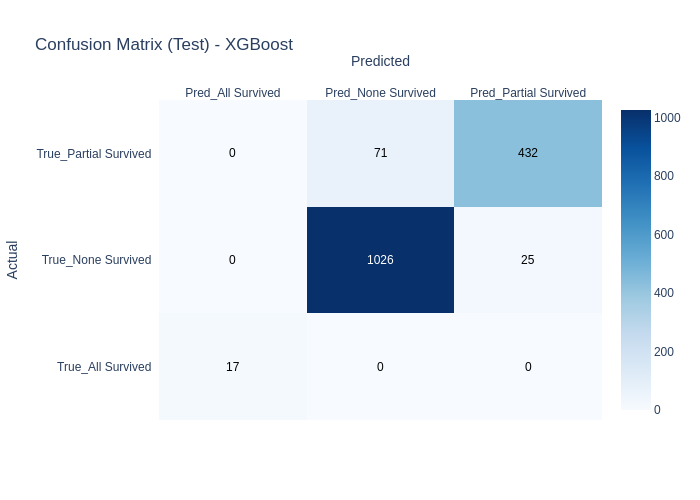

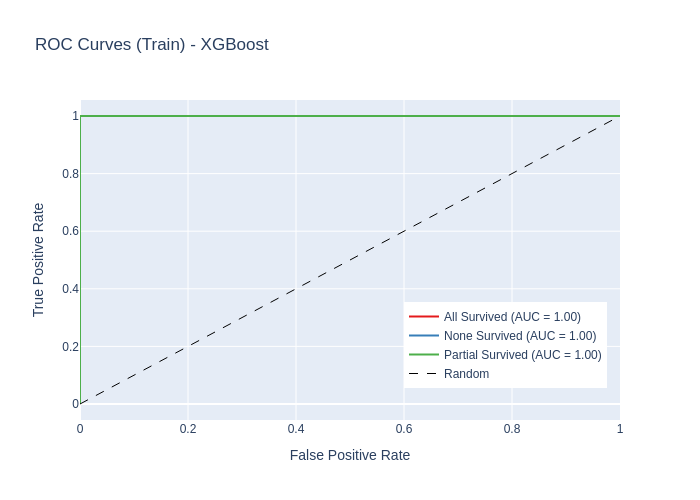

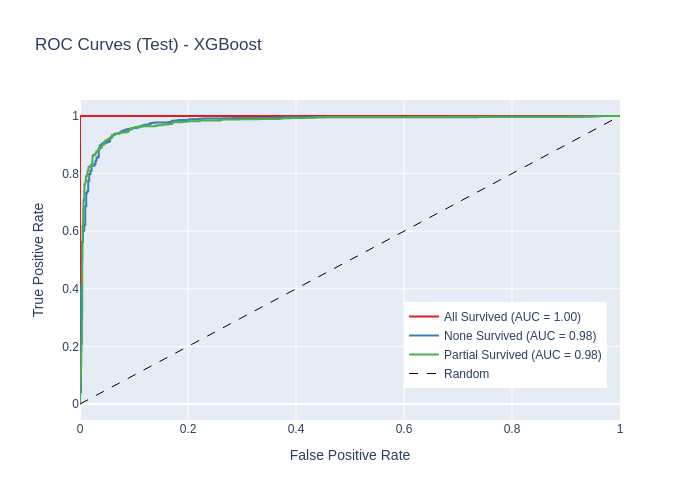


MODEL PERFORMANCE COMPARISON
              Model  Train_Accuracy  Train_Precision  Train_Recall  Train_F1  Train_AUC  Test_Accuracy  Test_Precision  Test_Recall  Test_F1  Test_AUC
Logistic Regression          0.9980           0.9980        0.9980    0.9980     1.0000         0.3405          0.3405       0.6366   0.2080    0.5635
      Decision Tree          0.9697           0.9713        0.9697    0.9697     0.9965         0.8861          0.8861       0.8852   0.8853    0.9037
      Random Forest          0.9294           0.9412        0.9294    0.9287     0.9945         0.7772          0.7772       0.7832   0.7523    0.8528
            XGBoost          1.0000           1.0000        1.0000    1.0000        NaN         0.9389          0.9389       0.9392   0.9381       NaN

BEST MODEL: XGBoost
Test Accuracy: 0.9389
Test Precision: 0.9389
Test Recall: 0.9392
Test F1 Score: 0.9381
Test AUC: nan

Results saved to 'model_comparison_results.csv'


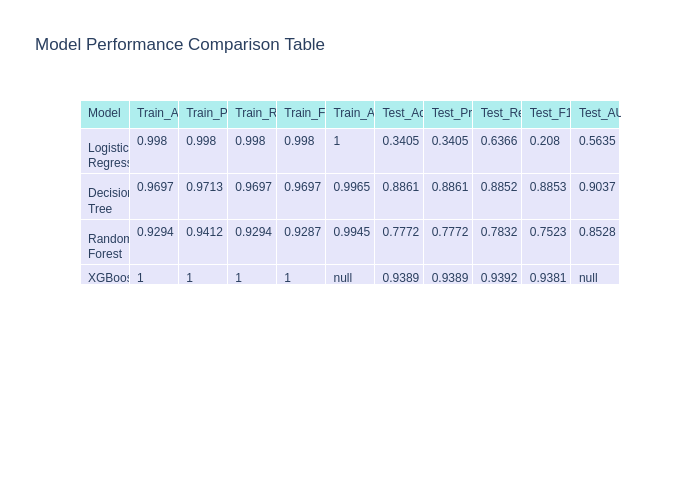

In [12]:
# Define models with hyperparameter grids
models = {
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42, max_iter=1000, multi_class='ovr'),
        'params': {
            'C': [0.1, 1, 10],
            'penalty': ['l2'], # Removed 'l1'
            'solver': ['liblinear'] # Removed 'saga' for L1 penalty incompatibility with ovr
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [3, 5, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'criterion': ['gini']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 10],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, eval_metric='mlogloss'),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 4, 5, 6],
            'learning_rate': [0.01, 0.1, 0.2],
            'subsample': [0.8, 0.9, 1.0]
        }
    }
}


# models = {
#     'Logistic Regression': {
#         'model': LogisticRegression(random_state=42, max_iter=1000, multi_class='ovr'),
#         'params': {
#             'C': [0.1, 1, 10],
#             'penalty': ['l2'],
#             'solver': ['liblinear']
#         }
#     },
#     'Decision Tree': {
#         'model': DecisionTreeClassifier(random_state=42),
#         'params': {
#             'max_depth': [5, 10, 15],
#             'min_samples_split': [2, 5],
#             'min_samples_leaf': [1, 2],
#             'criterion': ['gini']
#         }
#     },
#     'Random Forest': {
#         'model': RandomForestClassifier(random_state=42),
#         'params': {
#             'n_estimators': [50, 100],
#             'max_depth': [5, 10, 15],
#             'min_samples_split': [2, 5],
#             'min_samples_leaf': [1, 2]
#         }
#     },
#     'XGBoost': {
#         'model': XGBClassifier(random_state=42, eval_metric='mlogloss', enable_categorical=True),
#         'params': {
#             'n_estimators': [50, 100],
#             'max_depth': [3, 4, 5],
#             'learning_rate': [0.01, 0.1],
#             'subsample': [0.8, 1.0]
#         }
#     },
#     'SVM': {
#         'model': SVC(random_state=42, probability=True),
#         'params': {
#             'C': [0.1, 1, 10],
#             'kernel': ['rbf'],
#             'gamma': ['scale']
#         }
#     },
#     'Neural Network': {
#         'model': MLPClassifier(random_state=42, max_iter=1000),
#         'params': {
#             'hidden_layer_sizes': [(50,), (100,)],
#             'activation': ['relu'],
#             'alpha': [0.0001, 0.001],
#             'learning_rate': ['constant']
#         }
#     }
# }

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # Reduced folds

# Storage for results
trained_models = {}
results = {}

print("Starting hyperparameter tuning...")

# Identify categorical columns for encoding
categorical_cols = [col for col in X_train.columns if X_train[col].dtype == 'object']

# One-hot encode training data for linear models
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, dummy_na=False)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, dummy_na=False)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Ordinal encode for tree-based models
class RobustOrdinalEncoder:
    def __init__(self):
        self.encoders = {}
        self.categories = {}

    def fit(self, X, cols):
        for col in cols:
            unique_values = X[col].unique()
            self.categories[col] = unique_values
            value_to_int = {v: i for i, v in enumerate(unique_values)}
            self.encoders[col] = value_to_int
        return self

    def transform(self, X, cols):
        X_transformed = X.copy()
        for col in cols:
            X_transformed[col] = X[col].map(self.encoders[col]).fillna(-1).astype(int)
        return X_transformed

ordinal_encoder = RobustOrdinalEncoder().fit(X_train, categorical_cols)
X_train_ordinal = ordinal_encoder.transform(X_train, categorical_cols)
X_test_ordinal = ordinal_encoder.transform(X_test, categorical_cols)

# Encode target variable for XGBoost
label_encoder = LabelEncoder()
y_train_xgb = label_encoder.fit_transform(y_train)
y_test_xgb = label_encoder.transform(y_test)

# Keep original y for other models
y_train_original = y_train.copy()
y_test_original = y_test.copy()

# Determine the complete set of unique classes from the combined train and test sets
# This ensures label_binarize has all possible classes
all_classes = sorted(pd.concat([y_train, y_test]).unique())

# Train and tune each model
for name, config in models.items():
    print(f"\nTraining {name}...")

    # Select appropriate data
    if name in ['Logistic Regression', 'SVM', 'Neural Network']:
        X_train_model = X_train_encoded
        X_test_model = X_test_encoded
        y_train_model = y_train_original
        y_test_model = y_test_original
    else:  # Tree-based models
        X_train_model = X_train_ordinal
        X_test_model = X_test_ordinal
        y_train_model = y_train_xgb if name == 'XGBoost' else y_train_original
        y_test_model = y_test_xgb if name == 'XGBoost' else y_test_original

    # Grid search
    grid_search = GridSearchCV(
        config['model'],
        config['params'],
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train_model, y_train_model)

    # Store best model
    best_model = grid_search.best_estimator_
    trained_models[name] = best_model

    # Make predictions (convert back for XGBoost)
    if name == 'XGBoost':
        y_train_pred = label_encoder.inverse_transform(best_model.predict(X_train_model))
        y_test_pred = label_encoder.inverse_transform(best_model.predict(X_test_model))
        y_train_pred_proba = best_model.predict_proba(X_train_model)
        y_test_pred_proba = best_model.predict_proba(X_test_model)
    else:
        y_train_pred = best_model.predict(X_train_model)
        y_test_pred = best_model.predict(X_test_model)  # Class predictions
        y_train_pred_proba = best_model.predict_proba(X_train_model)
        y_test_pred_proba = best_model.predict_proba(X_test_model)

    results[name] = {
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred,
        'y_train_pred_proba': y_train_pred_proba,
        'y_test_pred_proba': y_test_pred_proba
    }

    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best CV score: {grid_search.best_score_:.4f}")

print("\nHyperparameter tuning completed!")

# Function to plot feature importance
def plot_feature_importance(model, feature_names, model_name, original_columns=None):
    """
    Parameters:
    - model: trained model
    - feature_names: list of feature names from the model
    - model_name: name of the model for title
    - original_columns: list of original predictor variables (before one-hot encoding)
    """
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        # Handle multi-class coefficients for linear models
        if model.coef_.ndim > 1:
            importances = np.abs(model.coef_).mean(axis=0)
        else:
            importances = np.abs(model.coef_)
    else:
        print(f"Feature importance not available for {model_name}")
        return None

    # For logistic regression with one-hot encoded features
    if model_name == 'Logistic Regression' and original_columns is not None:
        # Create a mapping from original columns to their one-hot encoded versions
        importance_dict = {}
        for orig_col in original_columns:
            # Find all one-hot encoded columns that start with this original column name
            encoded_cols = [f for f in feature_names if f.startswith(orig_col)]
            if encoded_cols:
                # Sum the importances for all one-hot encoded versions of this variable
                col_indices = [list(feature_names).index(col) for col in encoded_cols]
                importance_dict[orig_col] = np.sum(importances[col_indices])
            else:
                # For non-categorical variables that weren't one-hot encoded
                if orig_col in feature_names:
                    importance_dict[orig_col] = importances[list(feature_names).index(orig_col)]

        # Create DataFrame from the aggregated importances
        importance_df = pd.DataFrame({
            'feature': list(importance_dict.keys()),
            'importance': list(importance_dict.values())
        }).sort_values('importance', ascending=True)
    else:
        # For other models, use the features as-is
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        }).sort_values('importance', ascending=True)

    # Plot
    fig = go.Figure(go.Bar(
        x=importance_df['importance'],
        y=importance_df['feature'],
        orientation='h',
        marker_color='lightblue'
    ))

    fig.update_layout(
        title=f'Feature Importance - {model_name}',
        xaxis_title='Importance',
        yaxis_title='Features',
        height=max(400, len(importance_df) * 20)
    )

    return fig

# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, classes, title):
    # Ensure predictions are class labels, not probabilities
    if isinstance(y_pred, np.ndarray) and y_pred.ndim > 1:
        y_pred = np.argmax(y_pred, axis=1)  # Convert probabilities to class indices
        y_pred = [classes[i] for i in y_pred]  # Map to class names

    cm = confusion_matrix(y_true, y_pred, labels=classes) # Specify labels to ensure order

    # Create annotated heatmap
    fig = ff.create_annotated_heatmap(
        z=cm,
        x=[f'Pred_{cls}' for cls in classes],
        y=[f'True_{cls}' for cls in classes],
        annotation_text=cm,
        colorscale='Blues',
        showscale=True
    )

    fig.update_layout(
        title=title,
        xaxis_title='Predicted',
        yaxis_title='Actual'
    )

    return fig

# Function to plot ROC curves
def plot_roc_curves(y_true, y_pred_proba, classes, title):
    # Binarize the output
    y_true_bin = label_binarize(y_true, classes=classes)
    n_classes = len(classes)

    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # Ensure y_pred_proba has columns for all classes in the specified 'classes' order
    # If a class is missing in predictions, its probability column might be missing.
    # We need to handle this to align y_pred_proba with y_true_bin.

    # Get the order of classes from the model if available, otherwise assume the order in 'classes'
    if hasattr(y_pred_proba, 'classes_'):
        pred_proba_classes = list(y_pred_proba.classes_)
    else:
         # If predict_proba output is a numpy array, we need to know the column order.
         # This is tricky. Let's assume the order is the same as 'classes' for now,
         # but the previous fix for model.classes_ should handle most cases.
         # If this still fails, we might need to inspect the model's predict_proba output more carefully.
         pred_proba_classes = classes # Assuming order matches the input 'classes'


    # Reorder columns of y_pred_proba to match the order in 'classes'
    # Create a mapping from the model's class order to the desired 'classes' order
    col_order = [pred_proba_classes.index(c) for c in classes if c in pred_proba_classes]

    # Handle cases where some classes might be missing in the model's predict_proba output
    # This should ideally not happen if training was done correctly, but as a safeguard:
    if len(col_order) != n_classes:
        print(f"Warning: Mismatch between specified classes ({n_classes}) and predict_proba columns ({len(pred_proba_classes)}). Cannot plot ROC curves accurately.")
        return None # Return None if ROC plot cannot be generated


    y_pred_proba_ordered = y_pred_proba[:, col_order]


    for i in range(n_classes):
        # Handle the case where a class might have 0 true instances in the current subset
        if np.sum(y_true_bin[:, i]) == 0:
             roc_auc[i] = np.nan # AUC is not defined
             fpr[i], tpr[i] = [0, 1], [0, 1] # Plot a diagonal line or skip
             print(f"Warning: Class '{classes[i]}' has no true instances. Cannot calculate AUC.")
             continue

        # Handle the case where a class might have 0 predicted instances (or all predictions are 0 or 1)
        try:
            fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_proba_ordered[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
        except ValueError as e:
            print(f"Could not compute ROC curve for class '{classes[i]}': {e}")
            roc_auc[i] = np.nan
            fpr[i], tpr[i] = [0, 1], [0, 1] # Plot a diagonal line


    # Plot ROC curves
    fig = go.Figure()

    colors = px.colors.qualitative.Set1

    for i, color in zip(range(n_classes), cycle(colors)):
        # Only plot if AUC was computable
        if not np.isnan(roc_auc[i]):
            fig.add_trace(go.Scatter(
                x=fpr[i],
                y=tpr[i],
                mode='lines',
                name=f'{classes[i]} (AUC = {roc_auc[i]:.2f})',
                line=dict(color=color, width=2)
            ))
        else:
             # Optionally plot a dashed line for classes with no true instances or issues
             fig.add_trace(go.Scatter(
                x=fpr[i],
                y=tpr[i],
                mode='lines',
                name=f'{classes[i]} (AUC = N/A)',
                line=dict(color=color, width=1, dash='dash')
            ))


    # Add diagonal line
    fig.add_trace(go.Scatter(
        x=[0, 1],
        y=[0, 1],
        mode='lines',
        name='Random',
        line=dict(color='black', width=1, dash='dash')
    ))

    fig.update_layout(
        title=title,
        xaxis_title='False Positive Rate',
        yaxis_title='True Positive Rate',
        legend=dict(x=0.6, y=0.1)
    )

    return fig

# Get unique classes
# Ensure classes are derived from the combined train and test target for consistency
classes = sorted(pd.concat([y_train, y_test]).unique())

# Get original column names (before one-hot encoding)
original_columns = X_train.columns.tolist()

# Generate plots for each model
for name, model in trained_models.items():
    print(f"\nGenerating plots for {name}...")

    # Use appropriate feature names and original columns
    if name in ['Logistic Regression', 'SVM', 'Neural Network']:
        X_model_for_plots = X_train_encoded
        # For logistic regression, pass original columns to aggregate one-hot encoded features
        fig_importance = plot_feature_importance(
            model,
            X_model_for_plots.columns,
            name,
            original_columns=original_columns if name == 'Logistic Regression' else None
        )
    else:
        X_model_for_plots = X_train_ordinal if name != 'XGBoost' else X_train
        fig_importance = plot_feature_importance(model, X_model_for_plots.columns, name)

    if fig_importance:
        fig_importance.show()

    # Confusion matrices
    fig_cm_train = plot_confusion_matrix(
        y_train, results[name]['y_train_pred'], classes,
        f'Confusion Matrix (Train) - {name}'
    )
    fig_cm_train.show()

    fig_cm_test = plot_confusion_matrix(
        y_test, results[name]['y_test_pred'], classes,
        f'Confusion Matrix (Test) - {name}'
    )
    fig_cm_test.show()

    # ROC curves
    # Ensure y_pred_proba has the correct shape and order of classes
    # The plot_roc_curves function will now handle the reordering internally
    fig_roc_train = plot_roc_curves(
        y_train, results[name]['y_train_pred_proba'], classes,
        f'ROC Curves (Train) - {name}'
    )
    if fig_roc_train:
        fig_roc_train.show()


    fig_roc_test = plot_roc_curves(
        y_test, results[name]['y_test_pred_proba'], classes,
        f'ROC Curves (Test) - {name}'
    )
    if fig_roc_test:
        fig_roc_test.show()


# Function to calculate metrics
def calculate_metrics(y_true, y_pred, y_pred_proba, classes, model_name=None):
    """
    Calculate classification metrics.

    Parameters:
    - y_true: True labels
    - y_pred: Predicted labels
    - y_pred_proba: Predicted probabilities
    - classes: List of all possible classes
    - model_name: Name of the model (optional)
    """
    # Convert to pandas Categorical to ensure consistent handling
    y_true_cat = pd.Categorical(y_true, categories=classes)
    y_pred_cat = pd.Categorical(y_pred, categories=classes)

    accuracy = accuracy_score(y_true_cat, y_pred_cat)
    precision = precision_score(y_true_cat, y_pred_cat, average='weighted', zero_division=0)
    recall = recall_score(y_true_cat, y_pred_cat, average='weighted', zero_division=0)
    f1 = f1_score(y_true_cat, y_pred_cat, average='weighted', zero_division=0)

    # Initialize AUC as NaN (will compute if possible)
    auc_score = np.nan

    # Only compute AUC if we have probability predictions and more than one class
    if y_pred_proba is not None and len(classes) > 1:
        try:
            y_true_bin = label_binarize(y_true_cat, classes=classes)

            # Get the model to check class order if available
            model = trained_models.get(model_name) if model_name else None

            if model and hasattr(model, 'classes_'):
                model_classes = list(model.classes_)
                # Reorder probabilities to match the classes order
                col_order = [model_classes.index(c) for c in classes if c in model_classes]
                if len(col_order) == len(classes):
                    y_pred_proba_ordered = y_pred_proba[:, col_order]
                    auc_score = roc_auc_score(y_true_bin, y_pred_proba_ordered,
                                            average='weighted', multi_class='ovr')
            else:
                # Fallback: assume probabilities are in same order as classes
                if y_pred_proba.shape[1] == len(classes):
                    auc_score = roc_auc_score(y_true_bin, y_pred_proba,
                                            average='weighted', multi_class='ovr')
        except ValueError as e:
            print(f"Could not calculate AUC for {model_name}: {e}")

    return accuracy, precision, recall, f1, auc_score

# Calculate metrics for all models
metrics_data = []

for name in trained_models.keys():
    # Training metrics
    train_acc, train_prec, train_rec, train_f1, train_auc = calculate_metrics(
        y_train,
        results[name]['y_train_pred'],
        results[name]['y_train_pred_proba'],
        classes,
        model_name=name  # Pass the model name explicitly
    )

    # Testing metrics
    test_acc, test_prec, test_rec, test_f1, test_auc = calculate_metrics(
        y_test,
        results[name]['y_test_pred'],
        results[name]['y_test_pred_proba'],
        classes,
        model_name=name  # Pass the model name explicitly
    )

    metrics_data.append({
        'Model': name,
        'Train_Accuracy': train_acc,
        'Train_Precision': train_prec,
        'Train_Recall': train_rec,
        'Train_F1': train_f1,
        'Train_AUC': train_auc,
        'Test_Accuracy': test_acc,
        'Test_Precision': test_rec,
        'Test_Recall': test_prec,
        'Test_F1': test_f1,
        'Test_AUC': test_auc
    })

# Create comparison DataFrame
comparison_df = pd.DataFrame(metrics_data)

# Round to 4 decimal places
numeric_cols = [col for col in comparison_df.columns if col != 'Model']
comparison_df[numeric_cols] = comparison_df[numeric_cols].round(4)

print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))

# Find best model based on test recall
best_model_idx = comparison_df['Test_Recall'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']

print(f"\n" + "="*50)
print(f"BEST MODEL: {best_model_name}")
print("="*50)
print(f"Test Accuracy: {comparison_df.loc[best_model_idx, 'Test_Accuracy']:.4f}")
print(f"Test Precision: {comparison_df.loc[best_model_idx, 'Test_Precision']:.4f}")
print(f"Test Recall: {comparison_df.loc[best_model_idx, 'Test_Recall']:.4f}")
print(f"Test F1 Score: {comparison_df.loc[best_model_idx, 'Test_F1']:.4f}")
print(f"Test AUC: {comparison_df.loc[best_model_idx, 'Test_AUC']:.4f}")

# Save results
comparison_df.to_csv('model_comparison_results.csv', index=False)
print(f"\nResults saved to 'model_comparison_results.csv'")

# Display final comparison table as an interactive plot
fig_comparison = go.Figure(data=[go.Table(
    header=dict(values=list(comparison_df.columns),
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[comparison_df[col] for col in comparison_df.columns],
               fill_color='lavender',
               align='left'))
])

fig_comparison.update_layout(title="Model Performance Comparison Table")
fig_comparison.show()

**Part 1.3**: Selecting features covering **90% importance**

In [13]:
model = trained_models['XGBoost']
importances = model.feature_importances_
feature_names = X_train_ordinal.columns

# Create a DataFrame and sort
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False)

# Calculate cumulative importance
importance_df['cumulative'] = importance_df['importance'].cumsum()

# Select features covering 90% importance
selected_features = importance_df[importance_df['cumulative'] <= 0.9]['feature'].tolist()
print("Selected features:", selected_features)

Selected features: ['Fatalities', 'Aboard', 'Ground', 'FlightPhase', 'WaterBodyType', 'WeatherCondition', 'DayPeriod', 'CauseCategory']


**Part 1.4**: Retrain the **XGBoost** model with **selected features**

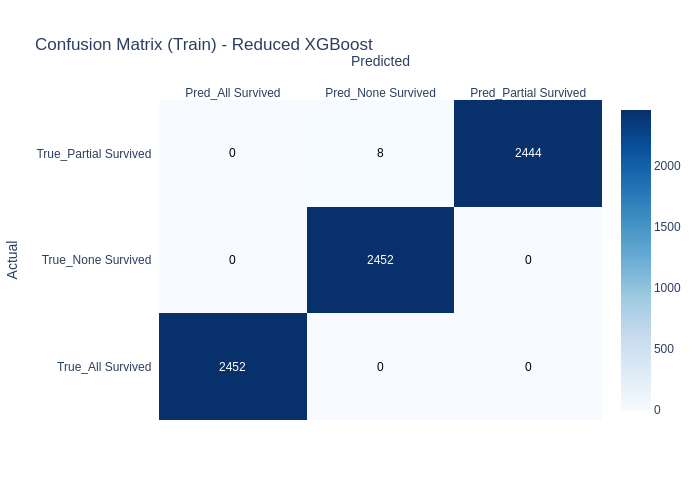

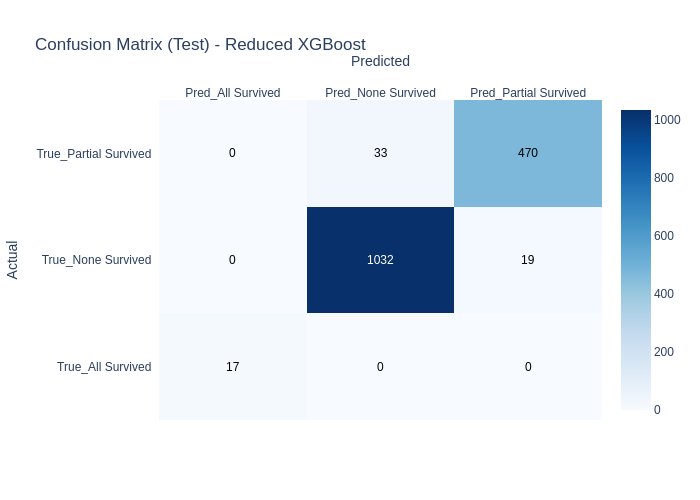

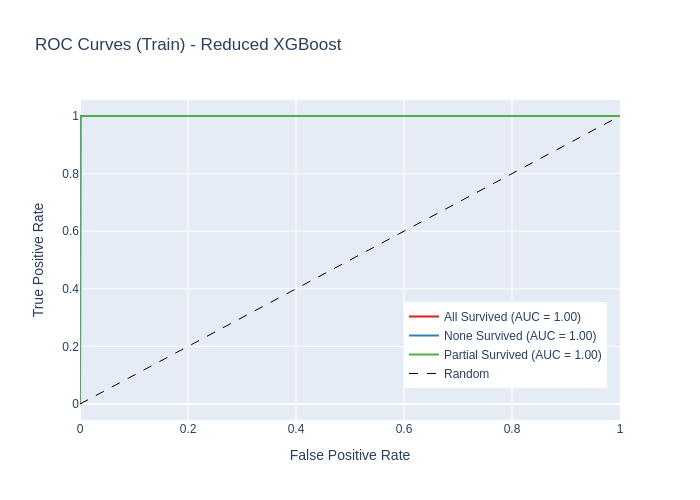

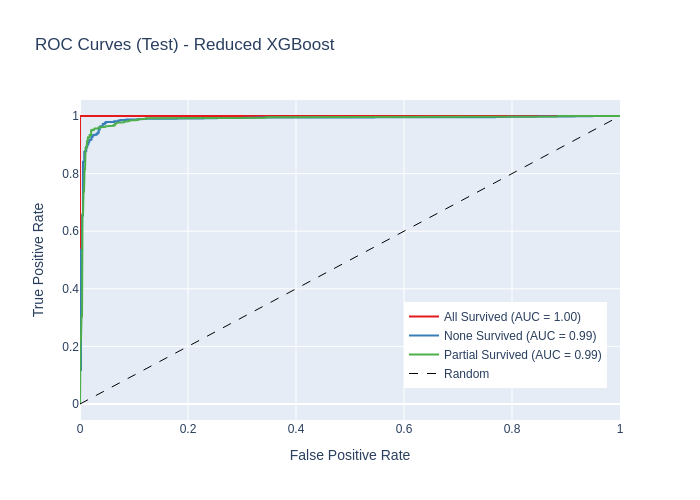


XGBoost Model Comparison:
            Model  Train_Accuracy  Train_Precision  Train_Recall  Train_F1  Train_AUC  Test_Accuracy  Test_Precision  Test_Recall  Test_F1  Test_AUC  Num_Features
   XGBoost (Full)          1.0000           1.0000        1.0000    1.0000        NaN         0.9337          0.9366       0.9366   0.9346       NaN            17
XGBoost (Reduced)          0.9989           0.9989        0.9989    0.9989        1.0         0.9669          0.9668       0.9669   0.9668    0.9889             8


In [14]:
# Prepare Reduced Feature Data

# For tree-based models (using ordinal encoded data)
X_train_reduced = X_train_ordinal[selected_features]
X_test_reduced = X_test_ordinal[selected_features]

# Train Reduced Feature XGBoost Model (Use same hyperparameters as best original model)
best_params = results['XGBoost']['best_params']

reduced_xgb = XGBClassifier(**best_params, random_state=42, eval_metric='mlogloss')
reduced_xgb.fit(X_train_reduced, y_train_xgb)

# Make predictions
y_train_pred_reduced = label_encoder.inverse_transform(reduced_xgb.predict(X_train_reduced))
y_test_pred_reduced = label_encoder.inverse_transform(reduced_xgb.predict(X_test_reduced))
y_train_proba_reduced = reduced_xgb.predict_proba(X_train_reduced)
y_test_proba_reduced = reduced_xgb.predict_proba(X_test_reduced)

# Generate Evaluation Metrics and Plots

# Training set confusion matrix
fig_cm_train_reduced = plot_confusion_matrix(
    y_train, y_train_pred_reduced, classes,
    'Confusion Matrix (Train) - Reduced XGBoost'
)
fig_cm_train_reduced.show()

# Test set confusion matrix
fig_cm_test_reduced = plot_confusion_matrix(
    y_test, y_test_pred_reduced, classes,
    'Confusion Matrix (Test) - Reduced XGBoost'
)
fig_cm_test_reduced.show()

# Training set ROC
fig_roc_train_reduced = plot_roc_curves(
    y_train, y_train_proba_reduced, classes,
    'ROC Curves (Train) - Reduced XGBoost'
)
fig_roc_train_reduced.show()

# Test set ROC
fig_roc_test_reduced = plot_roc_curves(
    y_test, y_test_proba_reduced, classes,
    'ROC Curves (Test) - Reduced XGBoost'
)
fig_roc_test_reduced.show()

# Create comprehensive comparison table
full_comparison = pd.DataFrame({
    'Model': ['XGBoost (Full)', 'XGBoost (Reduced)'],
    # Training metrics
    'Train_Accuracy': [1.0000, accuracy_score(y_train, y_train_pred_reduced)],
    'Train_Precision': [1.0000, precision_score(y_train, y_train_pred_reduced, average='weighted')],
    'Train_Recall': [1.0000, recall_score(y_train, y_train_pred_reduced, average='weighted')],
    'Train_F1': [1.0000, f1_score(y_train, y_train_pred_reduced, average='weighted')],
    'Train_AUC': [np.nan, roc_auc_score(label_binarize(y_train, classes=classes),
                               y_train_proba_reduced, average='weighted', multi_class='ovr')],
    # Test metrics
    'Test_Accuracy': [0.9337, accuracy_score(y_test, y_test_pred_reduced)],
    'Test_Precision': [0.9366, precision_score(y_test, y_test_pred_reduced, average='weighted')],
    'Test_Recall': [0.9366, recall_score(y_test, y_test_pred_reduced, average='weighted')],
    'Test_F1': [0.9346, f1_score(y_test, y_test_pred_reduced, average='weighted')],
    'Test_AUC': [np.nan, roc_auc_score(label_binarize(y_test, classes=classes),
                               y_test_proba_reduced, average='weighted', multi_class='ovr')],
    'Num_Features': [X_train_ordinal.shape[1], len(selected_features)]
})

print("\nXGBoost Model Comparison:")
print(full_comparison.round(4).to_string(index=False))

*   **Best Model** Determination (Focus on **Recall** for "None Survived" to avoid **missing fatal crashes**)


CONCLUSION: Reduced feature model performs equal or better!

Best Model: Reduced Feature XGBoost
Test Recall: 0.9669
Number of Features: 8


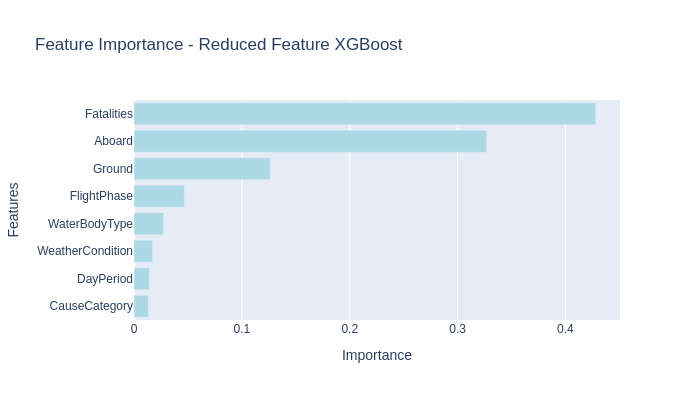

In [15]:
# Compare test recall
if full_comparison.loc[1, 'Test_Recall'] >= full_comparison.loc[0, 'Test_Recall']:
    best_model = reduced_xgb
    best_model_type = "Reduced Feature XGBoost"
    print("\nCONCLUSION: Reduced feature model performs equal or better!")
else:
    best_model = trained_models['XGBoost']
    best_model_type = "Full Feature XGBoost"
    print("\nCONCLUSION: Original model performs better")

print(f"\nBest Model: {best_model_type}")
print(f"Test Recall: {max(full_comparison['Test_Recall']):.4f}")
print(f"Number of Features: {best_model.n_features_in_ if hasattr(best_model, 'n_features_in_') else len(selected_features)}")

# Feature importance of best model
fig_importance = plot_feature_importance(
    best_model,
    selected_features if best_model_type == "Reduced Feature XGBoost" else X_train_ordinal.columns,
    best_model_type
)
fig_importance.show()

In [15]:
!pip install joblib

In [16]:
import joblib

# Save the retrained XGBoost model in MyDrive/Colab Notebooks/Data Analysis Project 1
joblib.dump(reduced_xgb, '/content/drive/MyDrive/Colab Notebooks/Data Analysis Project - Group 7/survival_severity_xgb.joblib')
print("XGBoost model saved as 'survival_severity_xgb.joblib'")

XGBoost model saved as 'survival_severity_xgb.joblib'


In [17]:
# Save the encodeers
joblib.dump(label_encoder, '/content/drive/MyDrive/Colab Notebooks/Data Analysis Project - Group 7/label_encoder.joblib')
print("Label encoder saved as 'label_encoder.joblib'")

joblib.dump(ordinal_encoder, '/content/drive/MyDrive/Colab Notebooks/Data Analysis Project - Group 7/ordinal_encoder.joblib')
print("Ordinal encoder saved as 'ordinal_encoder.joblib'")

Label encoder saved as 'label_encoder.joblib'
Ordinal encoder saved as 'ordinal_encoder.joblib'


In [18]:
# Save feature names
joblib.dump(selected_features, '/content/drive/MyDrive/Colab Notebooks/Data Analysis Project - Group 7/selected_features.joblib')
print("Selected features saved as 'selected_features.joblib'")

Selected features saved as 'selected_features.joblib'


**Part 1.5**: Interpreting the XGBoost with **SHAP** (SHapley Additive exPlanations)

In [19]:
!pip install shap

In [20]:
import shap

* **Global** Interpretation: SHAP **summary plots**

In [21]:
print("Class mappings:", label_encoder.classes_)

Class mappings: ['All Survived' 'None Survived' 'Partial Survived']


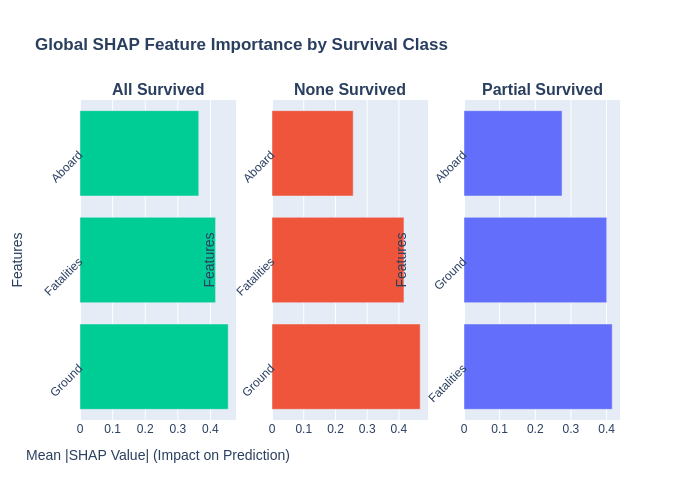

In [22]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Compute SHAP values (using your existing code)
selected_features = ['Fatalities', 'Aboard', 'Ground', 'FlightPhase',
                    'WaterBodyType', 'WeatherCondition', 'DayPeriod', 'CauseCategory']
X_selected = X_train_ordinal[selected_features]
explainer = shap.TreeExplainer(reduced_xgb)
shap_values = explainer.shap_values(X_selected)  # List of arrays [class0, class1, class2]

# 2. Get class names from label_encoder
class_names = label_encoder.classes_  # e.g., ['All Survived', 'None Survived', 'Partial Survived']

# 3. Prepare data for Plotly
mean_abs_shap = np.abs(shap_values).mean(axis=1)  # Mean |SHAP| per class
feature_order = np.argsort(mean_abs_shap.sum(axis=0))[::-1]  # Sort features by total importance

# 4. Create interactive plot
fig = make_subplots(rows=1, cols=len(class_names),
                   subplot_titles=[f"<b>{name}</b>" for name in class_names])

for i, class_name in enumerate(class_names):
    # Sort features by importance for this class
    idx = np.argsort(mean_abs_shap[i])[::-1]

    fig.add_trace(
        go.Bar(
            x=mean_abs_shap[i][idx],
            y=[selected_features[j] for j in idx],
            orientation='h',
            name=class_name,
            marker_color=['#00CC96', '#EF553B', '#636EFA'][i]  # Red/Blue/Green
        ),
        row=1, col=i+1
    )

# Update layout
fig.update_layout(
    title_text="<b>Global SHAP Feature Importance by Survival Class</b>",
    height=500,
    showlegend=False,
    xaxis_title="Mean |SHAP Value| (Impact on Prediction)"
)
fig.update_yaxes(title_text="Features", tickangle=-45)
fig.show()

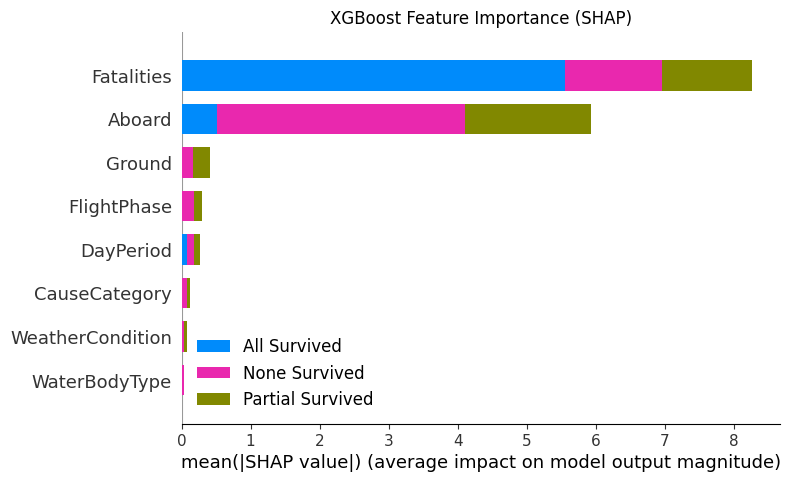

In [25]:
import matplotlib.pyplot as plt

# Prepare data with selected features
selected_features = ['Fatalities', 'Aboard', 'Ground', 'FlightPhase', 'WaterBodyType', 'WeatherCondition', 'DayPeriod', 'CauseCategory']
X_selected = X_train_ordinal[selected_features]  # Using ordinal encoded data

# Create SHAP explainer
explainer = shap.TreeExplainer(reduced_xgb)
shap_values = explainer.shap_values(X_selected)


# Global feature importance
shap.summary_plot(shap_values, X_selected, plot_type="bar", class_names = label_encoder.classes_, show=False)
plt.title("XGBoost Feature Importance (SHAP)")
plt.show()

**Part 1.6**: Interpreting the XGBoost with **PDPs** (Partial Dependence Plots)

In [26]:
!pip install pdpbox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.3/69.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 10.8 MB/s eta 0:00:00


In [1]:
import pdpbox

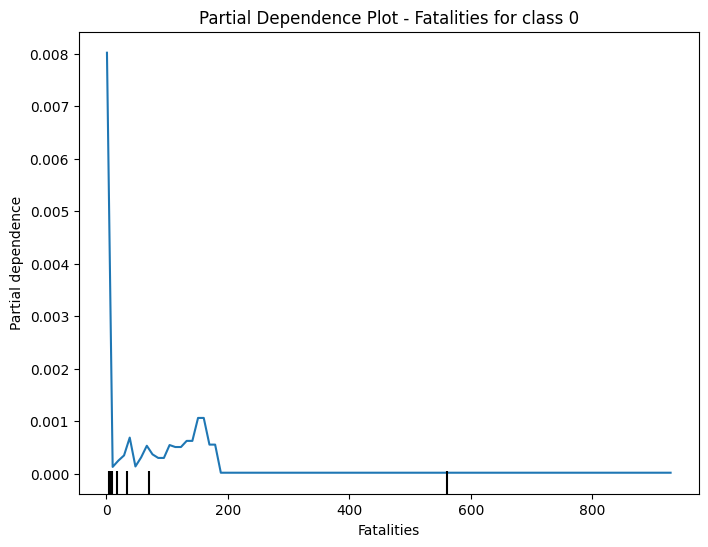

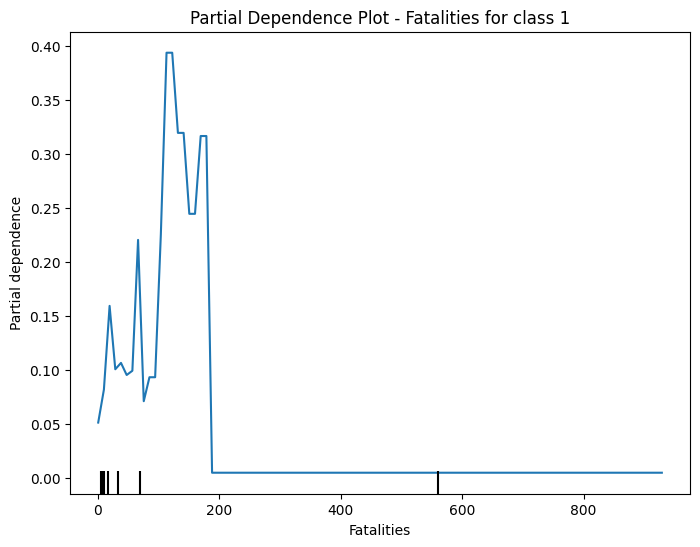

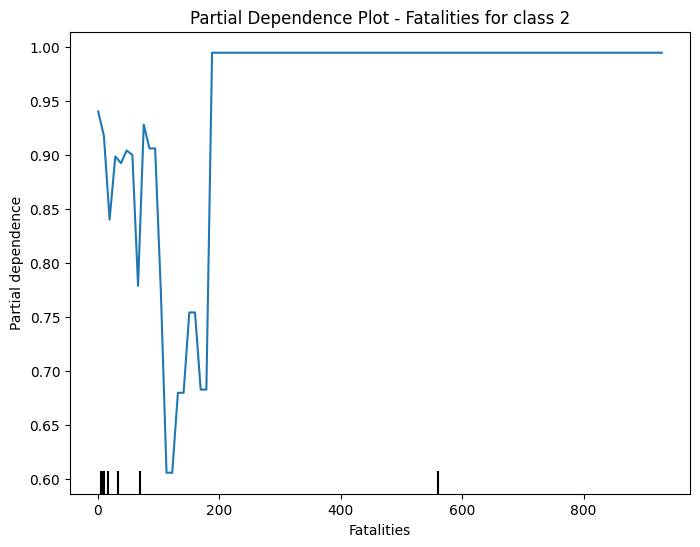

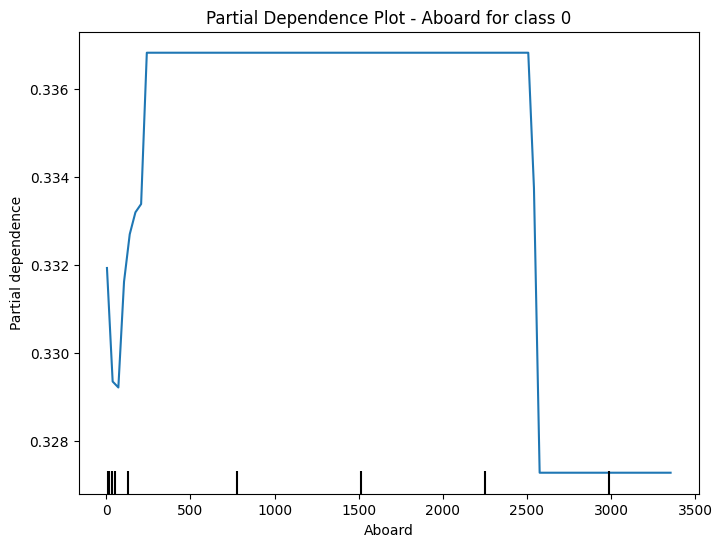

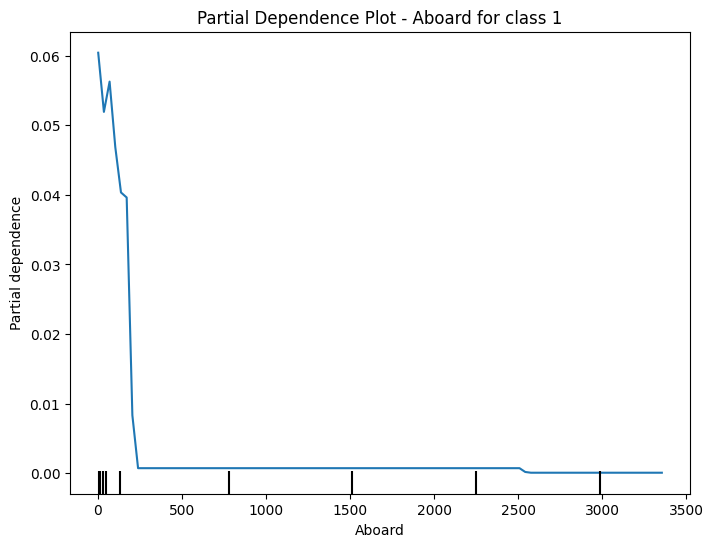

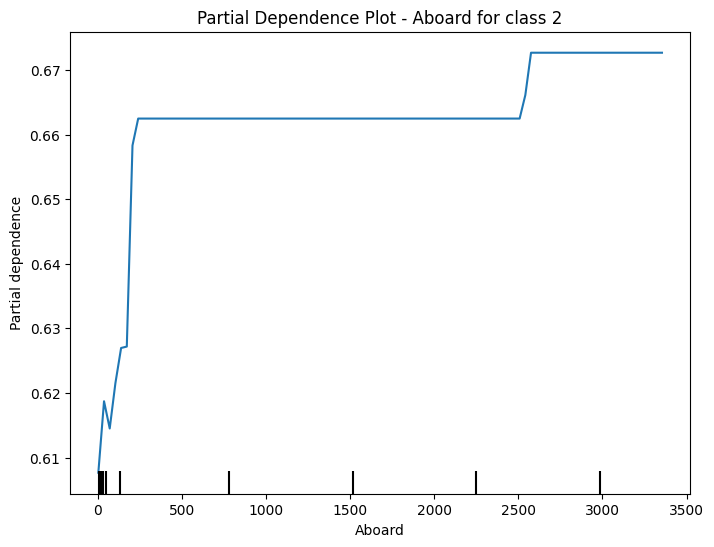

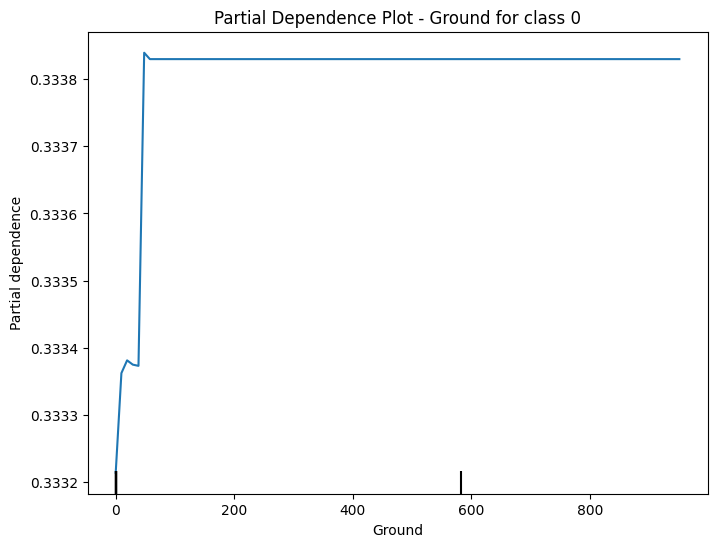

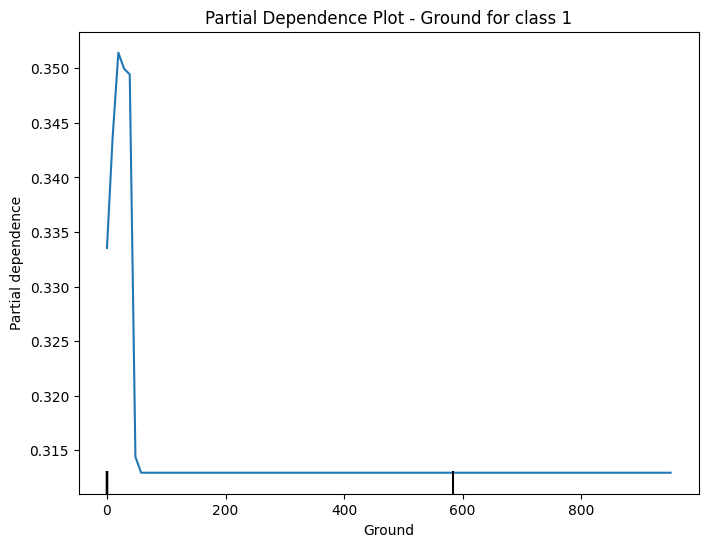

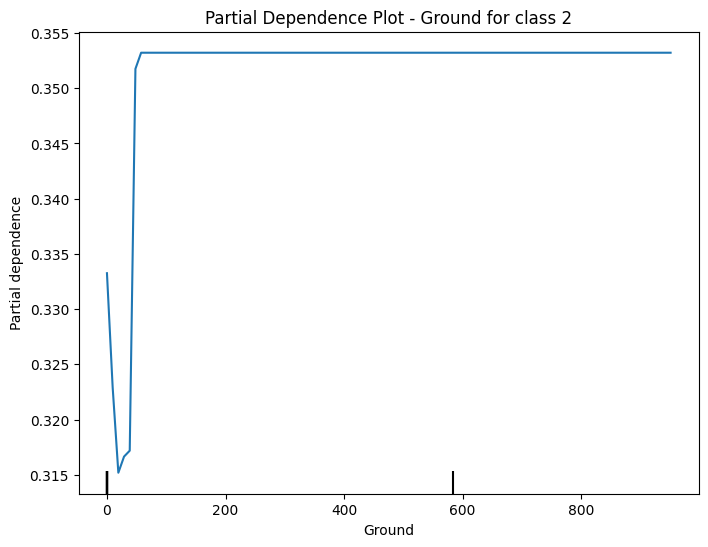

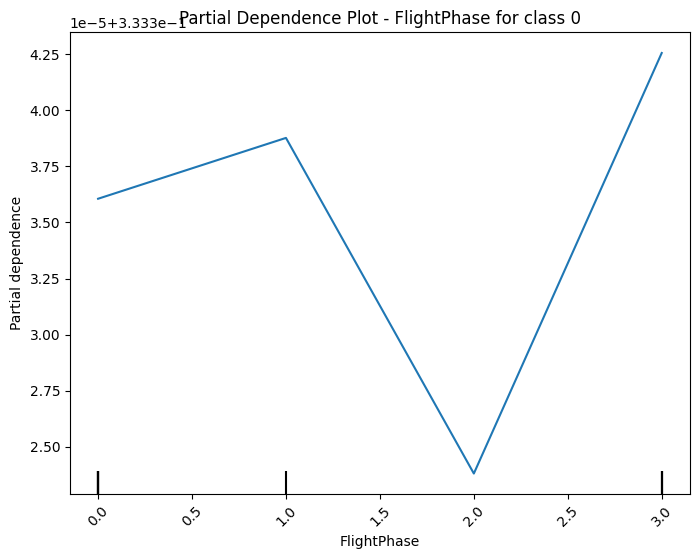

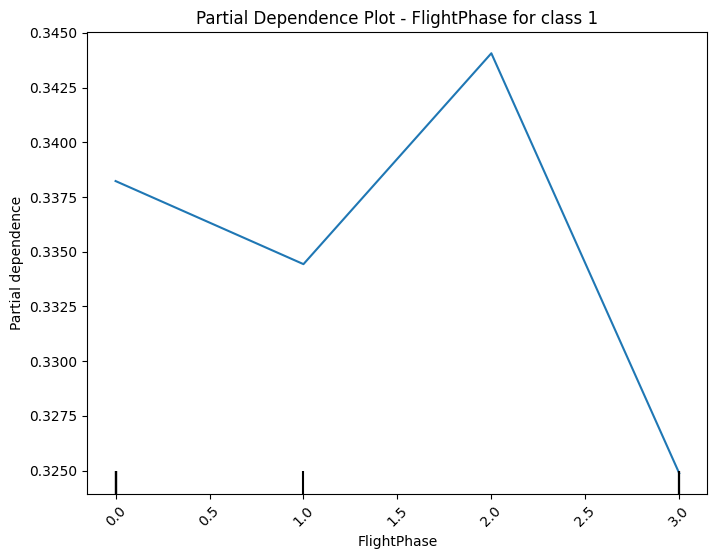

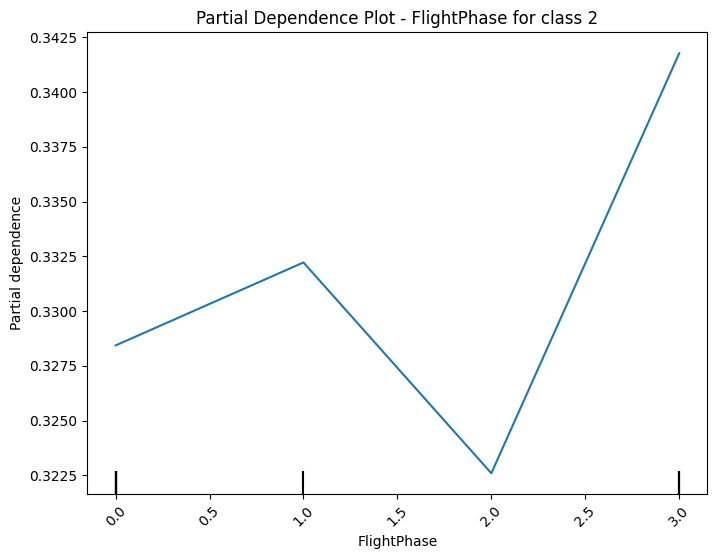

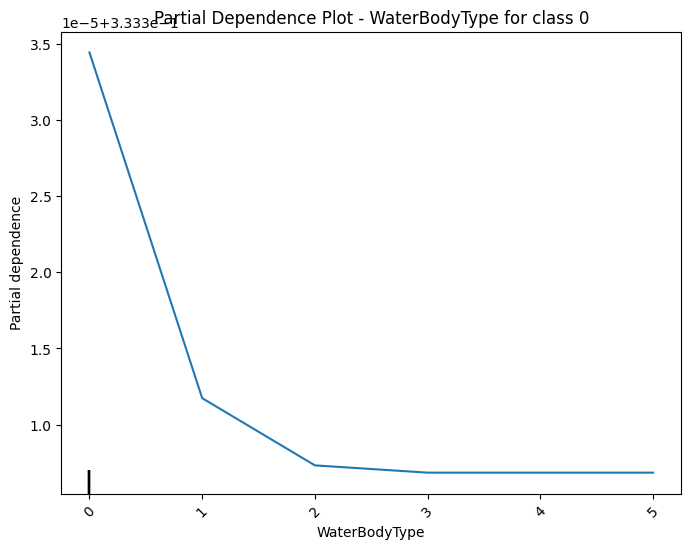

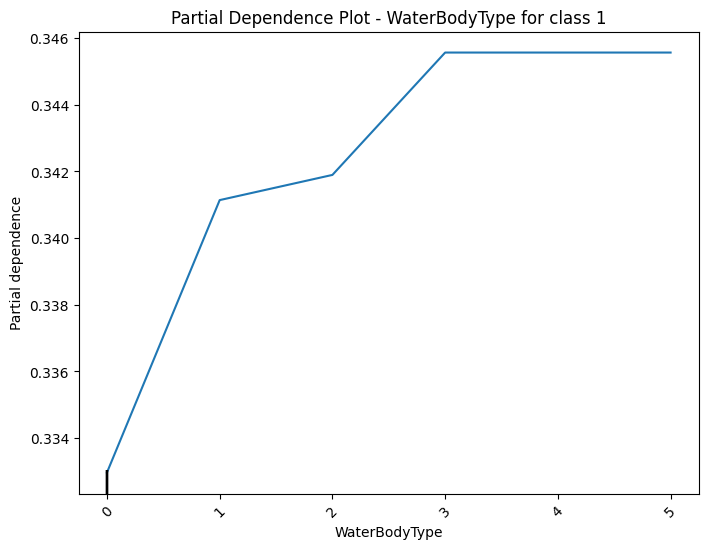

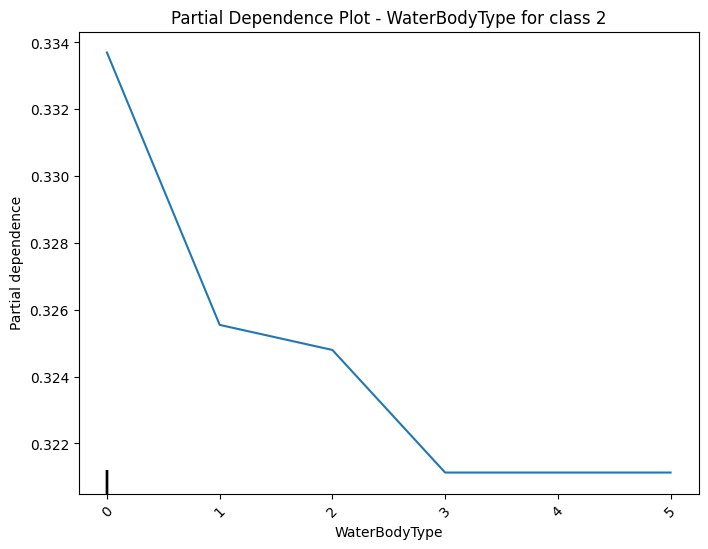

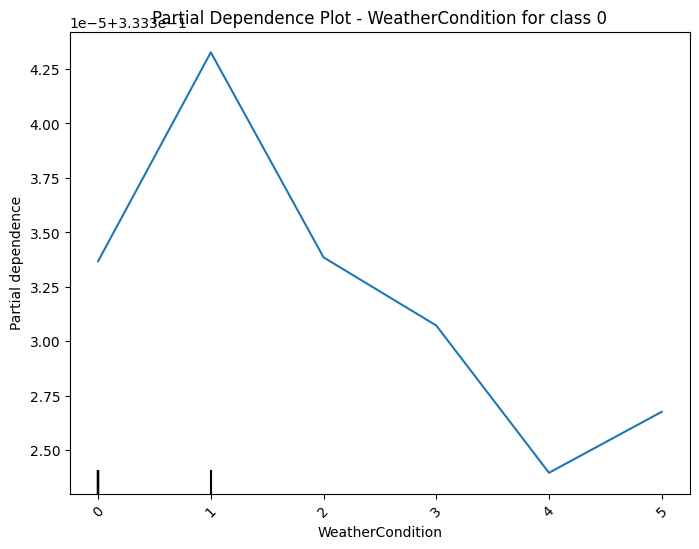

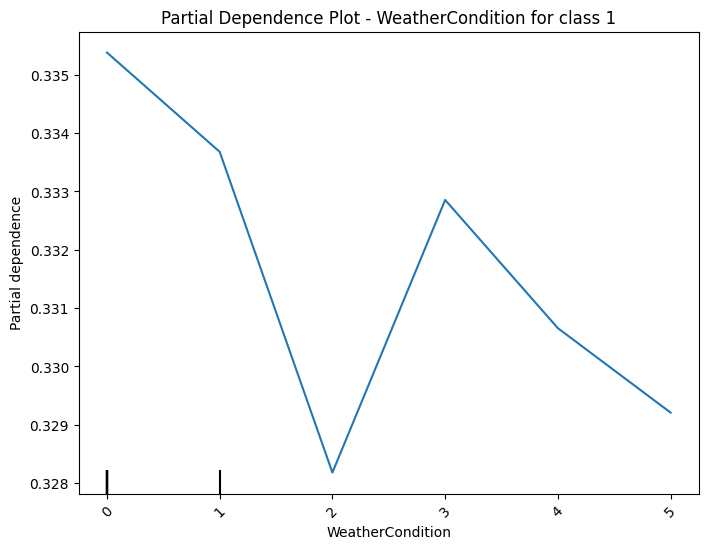

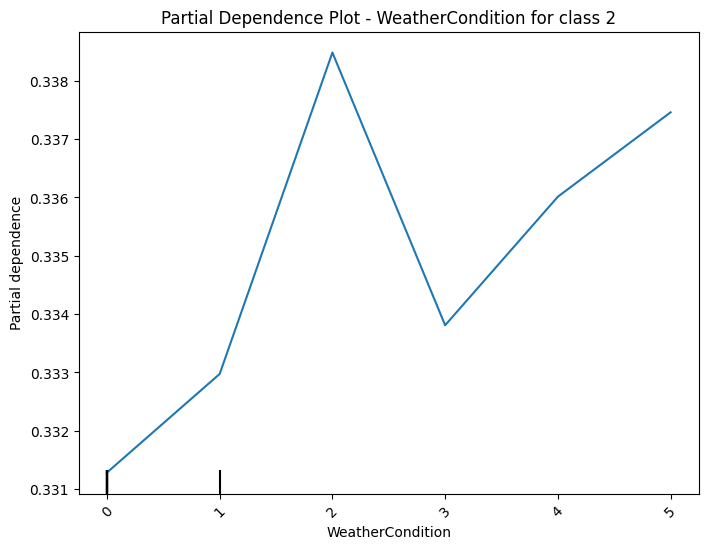

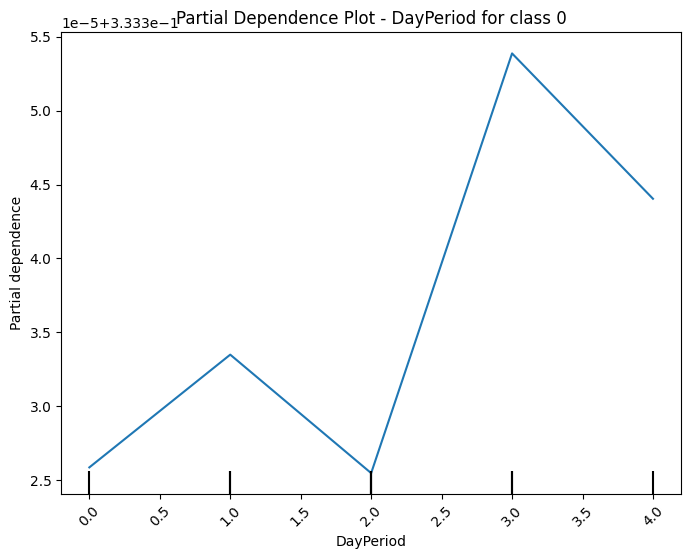

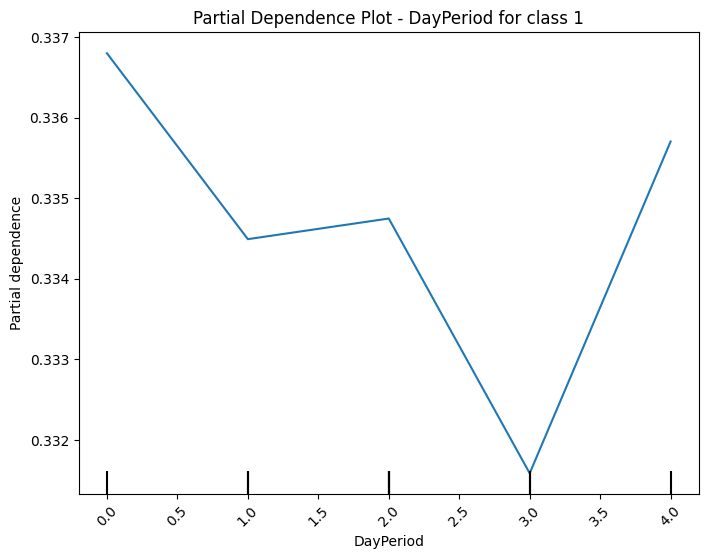

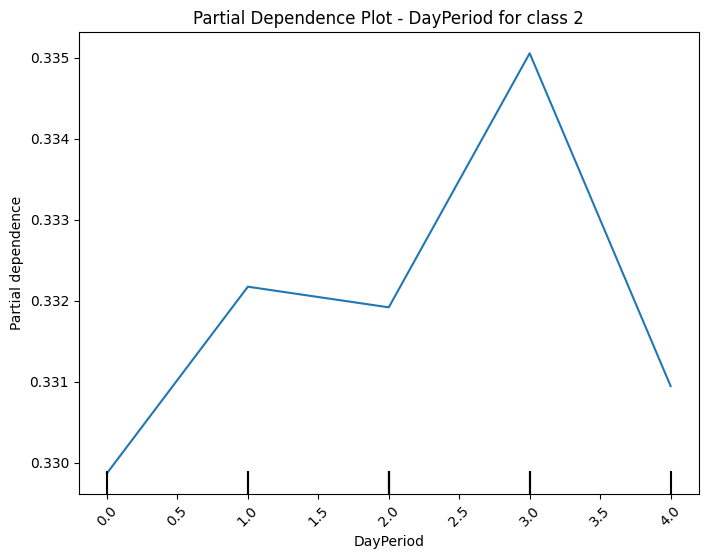

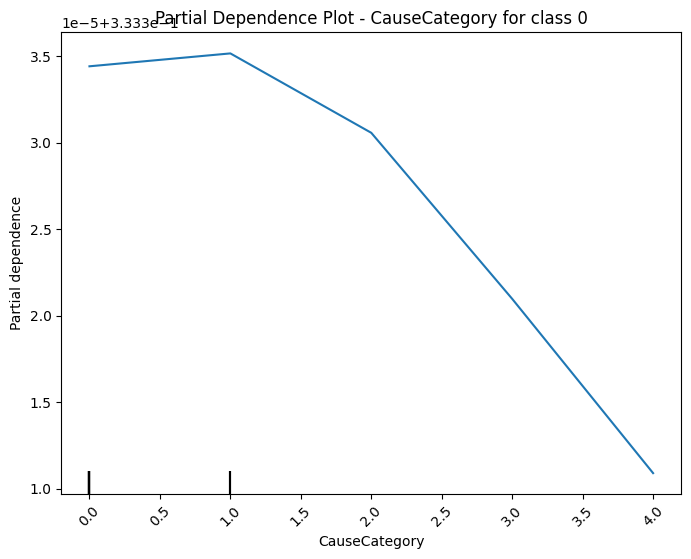

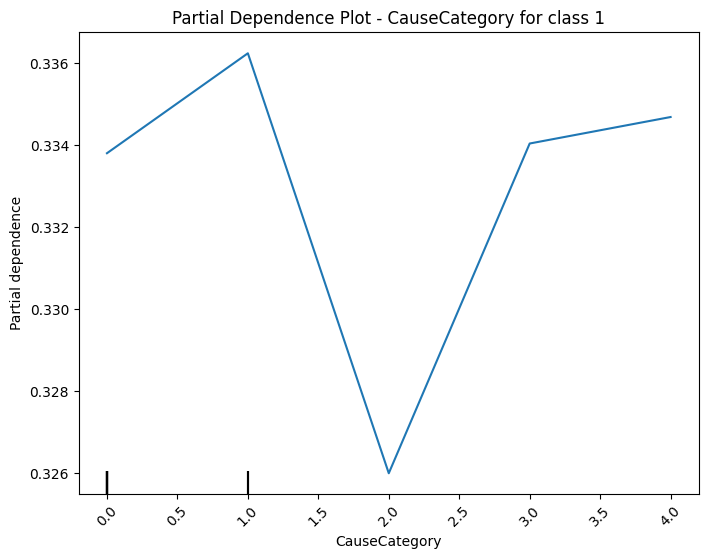

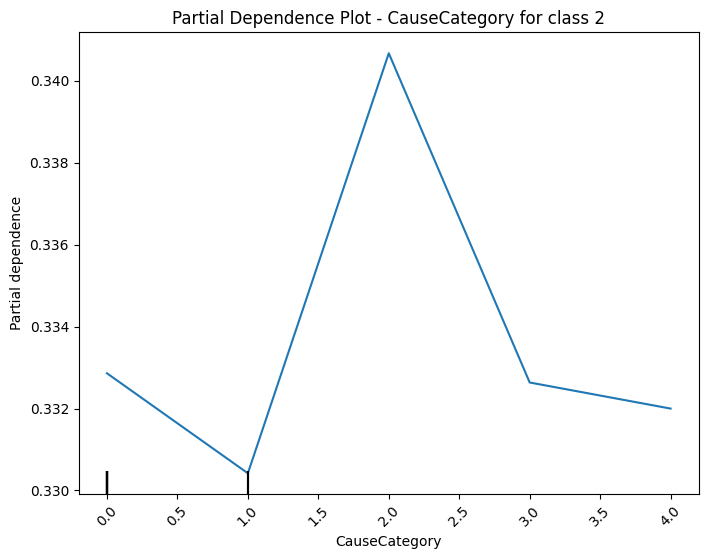

In [17]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# For numeric features
for feature in ['Fatalities', 'Aboard', 'Ground']:
    for target_class in reduced_xgb.classes_:
        fig, ax = plt.subplots(figsize=(8, 6))
        display = PartialDependenceDisplay.from_estimator(
            estimator=reduced_xgb,
            X=X_train_ordinal[selected_features],
            features=[feature],
            target=target_class,
            ax=ax
        )
        ax.set_title(f"Partial Dependence Plot - {feature} for class {target_class}")
        plt.show()

# For categorical features
for feature in ['FlightPhase', 'WaterBodyType', 'WeatherCondition', 'DayPeriod', 'CauseCategory']:
    for target_class in reduced_xgb.classes_:
        fig, ax = plt.subplots(figsize=(8, 6))
        display = PartialDependenceDisplay.from_estimator(
            estimator=reduced_xgb,
            X=X_train_ordinal[selected_features],
            features=[feature],
            target=target_class,
            ax=ax
        )
        ax.set_title(f"Partial Dependence Plot - {feature} for class {target_class}")
        plt.xticks(rotation=45)
        plt.show()



---



# **Approach 2**: Using the **Interpreted PCA-MCA Componets**

In [18]:
X_combined = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Data Analysis Project - Group 7/X_combined.csv")

In [ ]:
X_combined

In [19]:
# Select top components
X_reduced = X_combined[['PC1', 'PC2', 'MCA1', 'MCA2', 'MCA3', 'MCA4']]
y = X_combined['SurvivalSeverity']

# Train-test split (maintaining same random_state for comparison)
X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(
    X_reduced, y, test_size=0.3, random_state=42, stratify=y
)

In [20]:
train_df_reduced = pd.concat([X_train_reduced, y_train_reduced], axis=1)
test_df_reduced = pd.concat([X_test_reduced, y_test_reduced], axis=1)

# Save to CSV files
train_df_reduced.to_csv("/content/drive/MyDrive/Colab Notebooks/Data Analysis Project - Group 7/train_reduced.csv", index=False)
test_df_reduced.to_csv("/content/drive/MyDrive/Colab Notebooks/Data Analysis Project - Group 7/test_reduced.csv", index=False)

**Part 2.1**: Applying **SMOTE**

In [21]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline  # Special pipeline that handles resampling

# Initialize SMOTE (adjust sampling_strategy if needed)
smote = SMOTE(random_state=42, sampling_strategy='auto')  # 'auto' balances all classes to match the majority

# Apply SMOTE only to the training set
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_reduced, y_train_reduced)

* Check the distribution of **SurvivalSeverity** after applying SMOTE

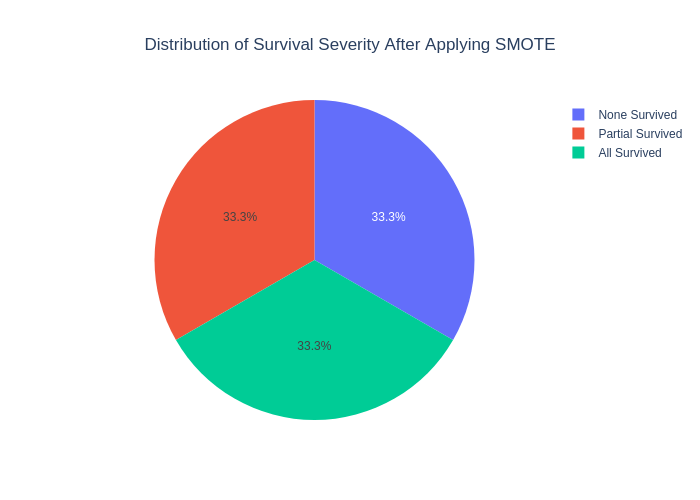

In [22]:
# Counts
severityCounts = y_train_resampled.value_counts().reset_index()
severityCounts.columns = ['SurvivalSeverity', 'Count']

# Plot
fig14 = px.pie(
    severityCounts,
    names='SurvivalSeverity',
    values='Count',
    title='Distribution of Survival Severity After Applying SMOTE',
    labels={'SurvivalSeverity': 'Survival Severity', 'Count': 'No. of Crashes'}
)

fig14.update_layout(
    title_x=0.5
)

fig14.show()

**Part 2.2**: Training Classification Models

*   **Baseline Model**: Multivariate Logistic Regression
*   **Tree Based Models**: Classification Trees, Random Forest, XGBoost

Starting hyperparameter tuning for dimensionality reduced dataset...
Training data shape: (7356, 6)
Test data shape: (1571, 6)
Features: ['PC1', 'PC2', 'MCA1', 'MCA2', 'MCA3', 'MCA4']
Classes: ['All Survived', 'None Survived', 'Partial Survived']

Training Logistic Regression...
Best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV score: 0.4753

Training Decision Tree...
Best parameters: {'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV score: 0.7928

Training Random Forest...
Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 0.7904

Training XGBoost...
Best parameters: {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.9}
Best CV score: 0.9496

Hyperparameter tuning completed!

Generating plots for Logistic Regression (Reduced Dimensions)...


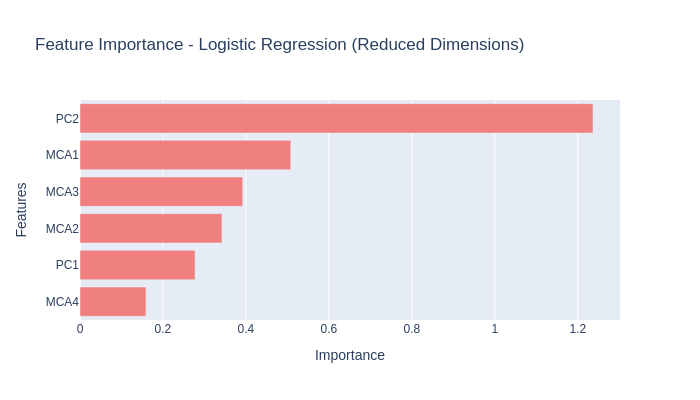

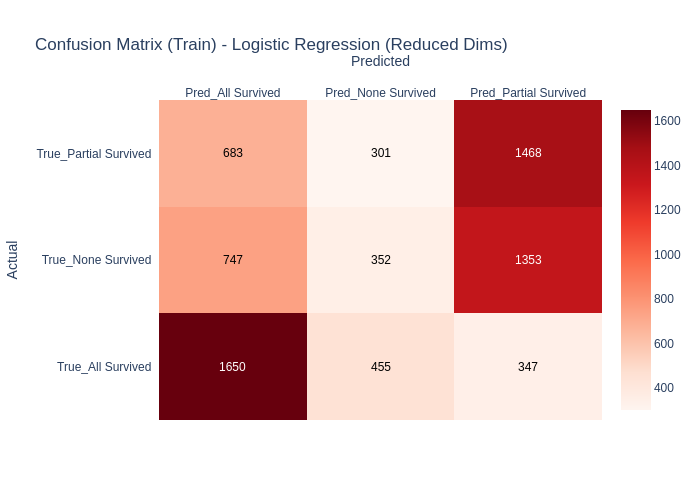

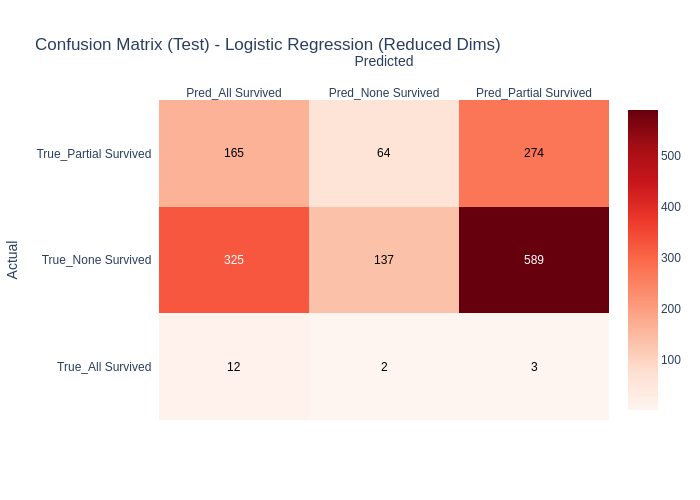

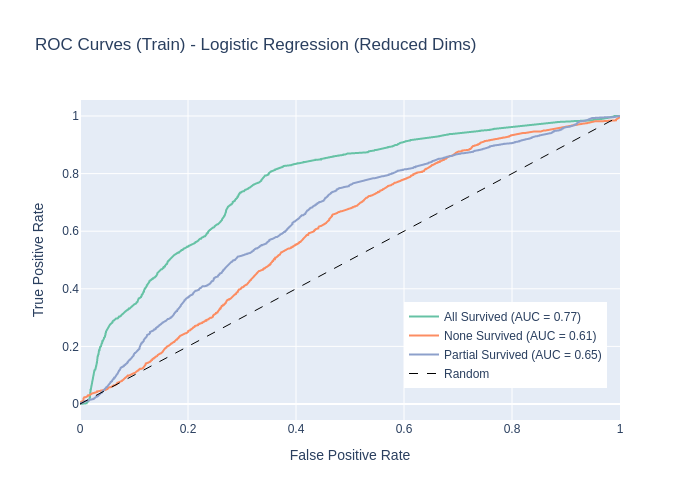

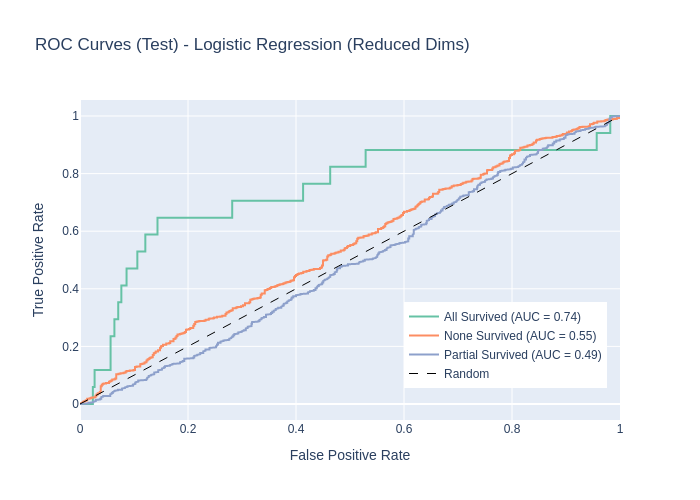


Generating plots for Decision Tree (Reduced Dimensions)...


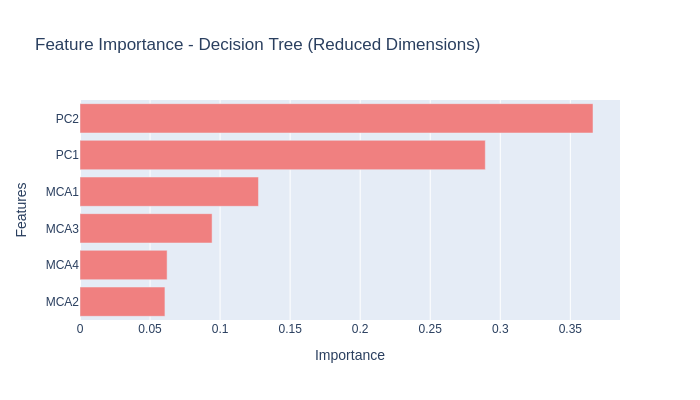

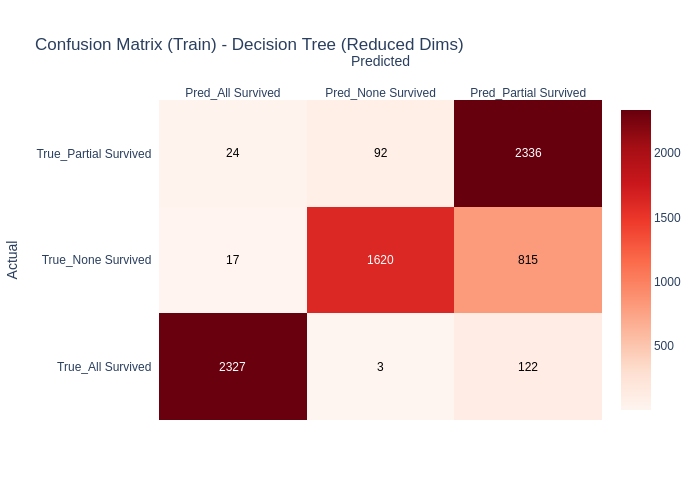

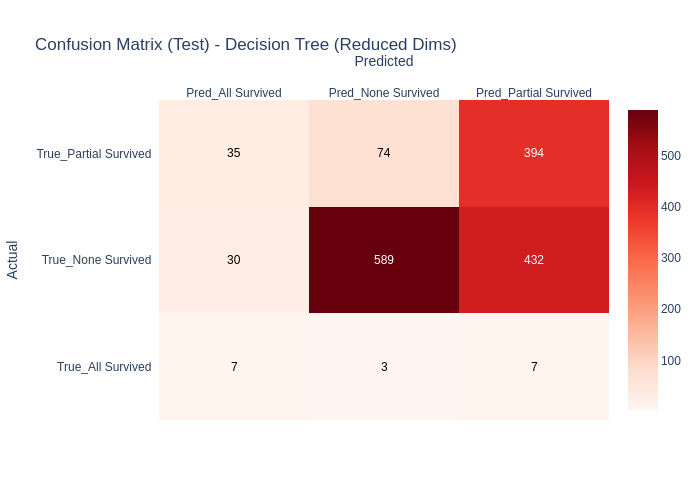

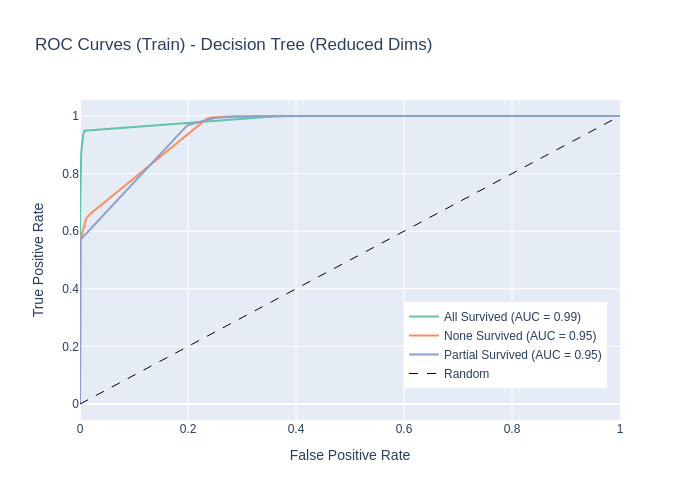

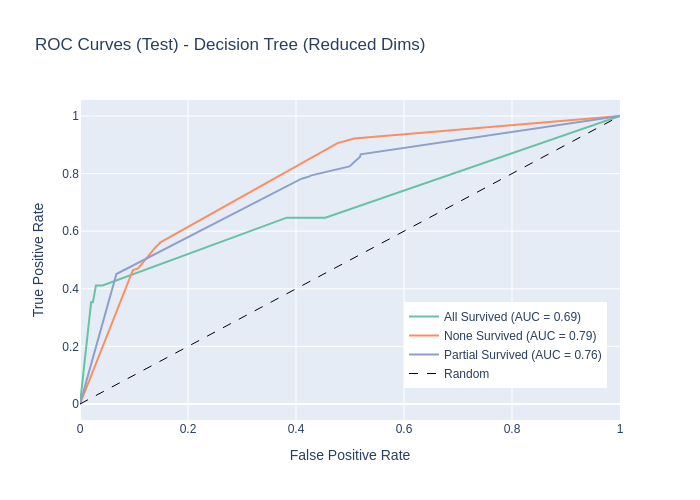


Generating plots for Random Forest (Reduced Dimensions)...


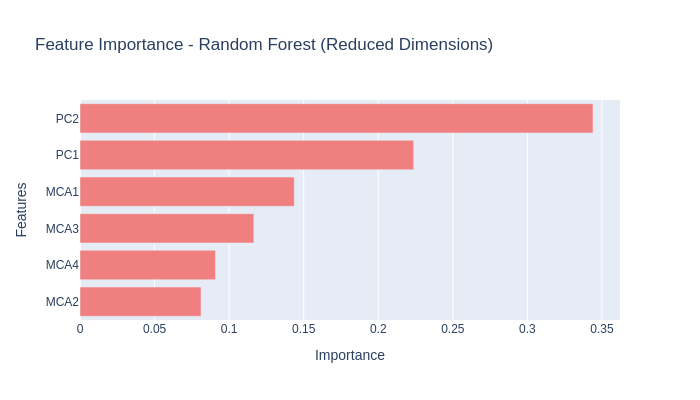

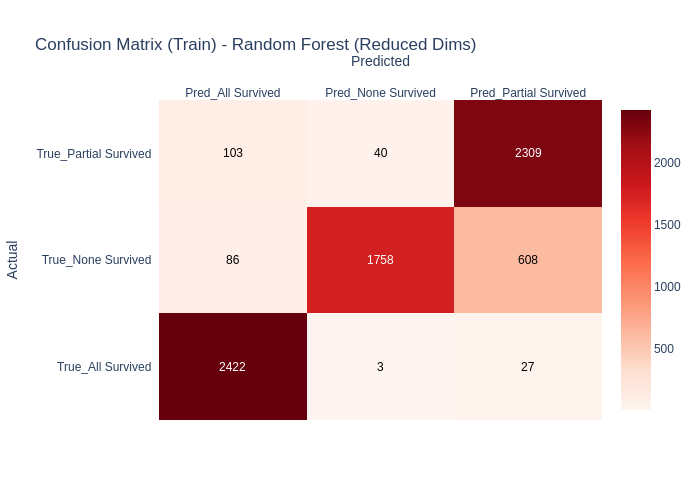

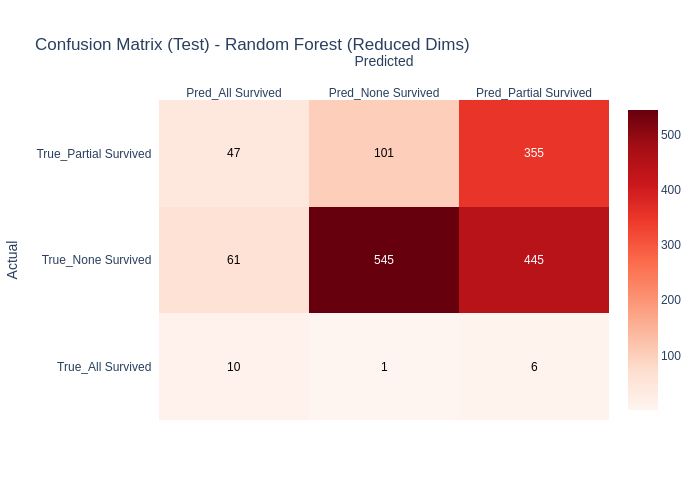

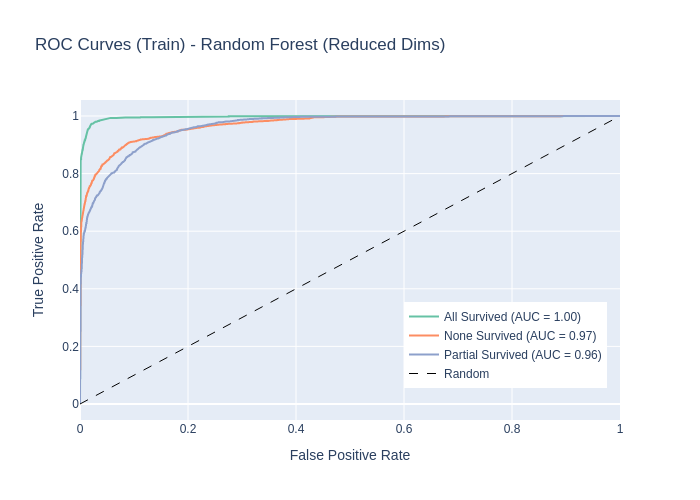

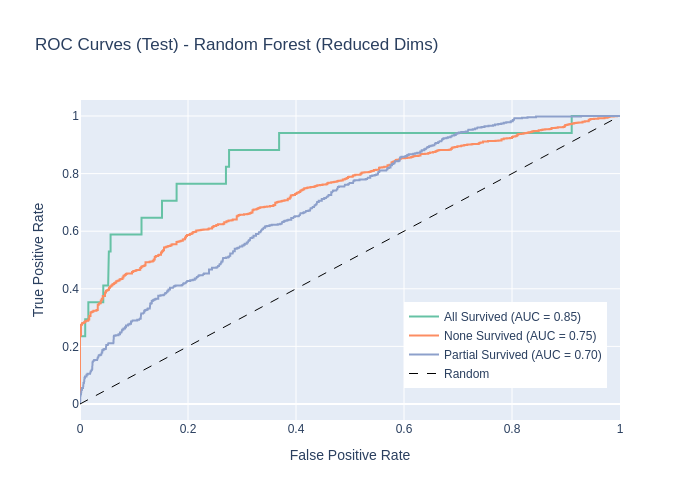


Generating plots for XGBoost (Reduced Dimensions)...


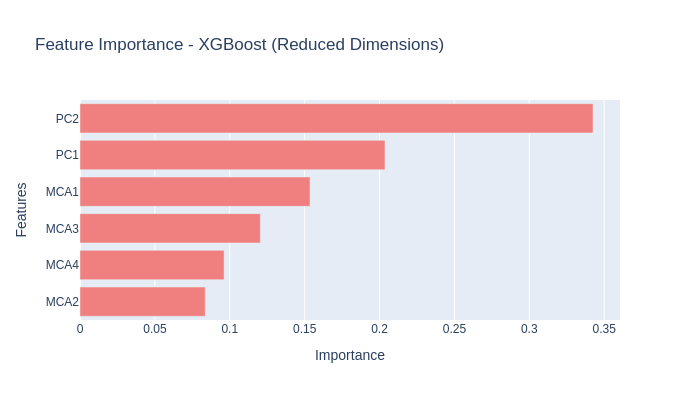

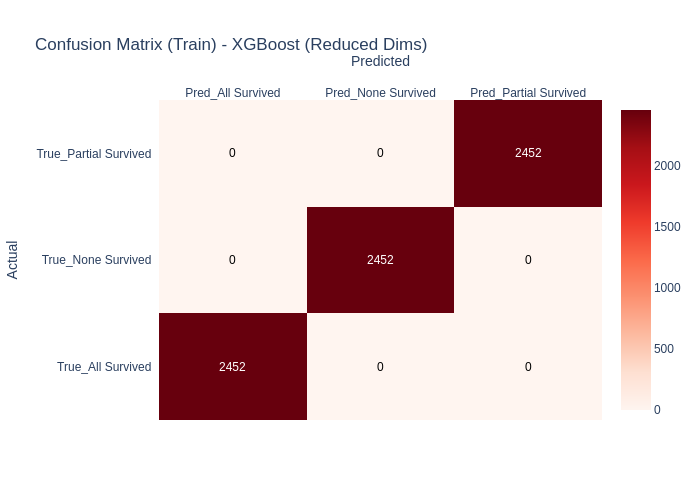

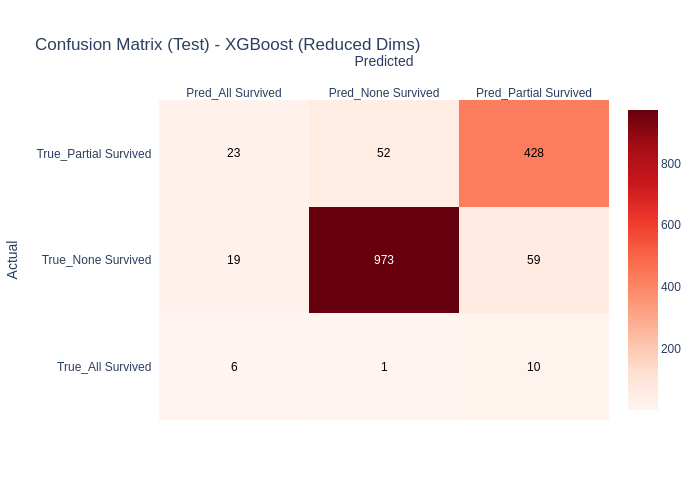

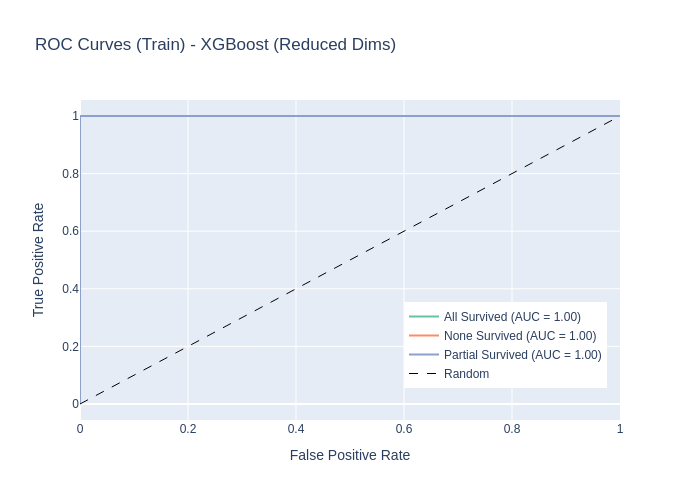

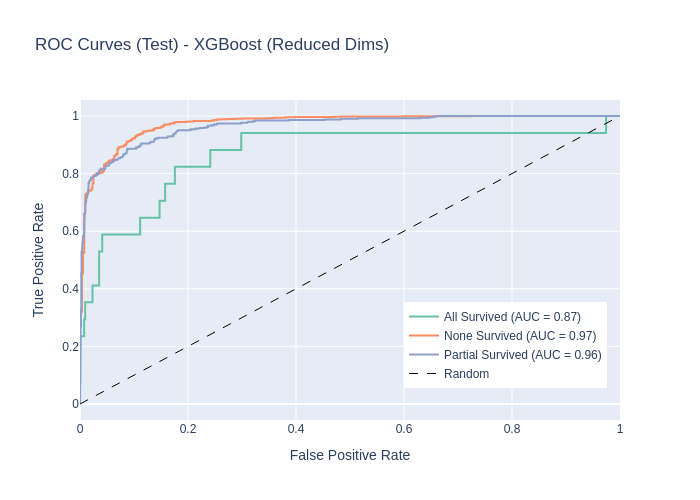


MODEL PERFORMANCE COMPARISON (REDUCED DIMENSIONS)
              Model  Train_Accuracy  Train_Precision  Train_Recall  Train_F1  Train_AUC  Test_Accuracy  Test_Precision  Test_Recall  Test_F1  Test_AUC
Logistic Regression          0.4717           0.4389        0.4717    0.4389     0.6736         0.2693          0.5531       0.2693   0.2748    0.5281
      Decision Tree          0.8541           0.8803        0.8541    0.8531     0.9657         0.6302          0.7441       0.6302   0.6495    0.7810
      Random Forest          0.8821           0.8960        0.8821    0.8798     0.9770         0.5792          0.7055       0.5792   0.6047    0.7360
            XGBoost          1.0000           1.0000        1.0000    1.0000        NaN         0.8956          0.9115       0.8956   0.9029       NaN

BEST MODEL (REDUCED DIMENSIONS): XGBoost
Test Accuracy: 0.8956
Test Precision: 0.9115
Test Recall: 0.8956
Test F1 Score: 0.9029
Test AUC: nan

Results saved to 'model_comparison_results_reduced

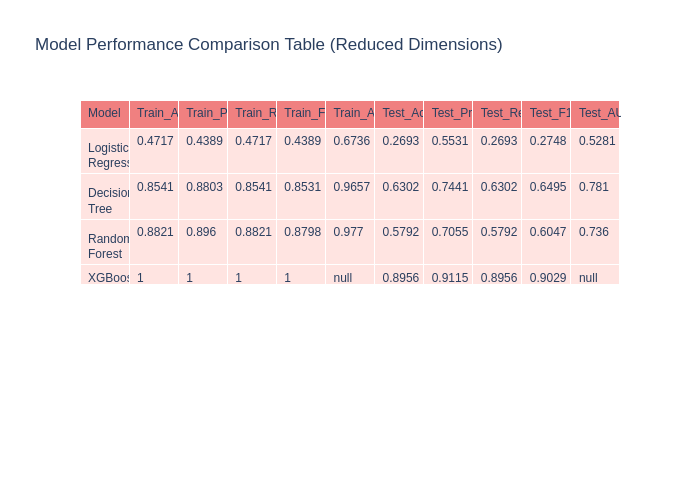


FEATURE INFORMATION (REDUCED DIMENSIONS)
Original features reduced from 17 to 6 dimensions
Features used: ['PC1', 'PC2', 'MCA1', 'MCA2', 'MCA3', 'MCA4']
Training set size after SMOTE: 7356 samples
Test set size: 1571 samples


In [23]:
# Define models with hyperparameter grids for reduced dimensions
models_reduced = {
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42, max_iter=1000, multi_class='ovr'),
        'params': {
            'C': [0.1, 1, 10],
            'penalty': ['l2'],
            'solver': ['liblinear']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [3, 5, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'criterion': ['gini']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 10],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, eval_metric='mlogloss'),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 4, 5, 6],
            'learning_rate': [0.01, 0.1, 0.2],
            'subsample': [0.8, 0.9, 1.0]
        }
    }
}

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for results
trained_models_reduced = {}
results_reduced = {}

print("Starting hyperparameter tuning for dimensionality reduced dataset...")
print(f"Training data shape: {X_train_resampled.shape}")
print(f"Test data shape: {X_test_reduced.shape}")
print(f"Features: {list(X_train_resampled.columns)}")

# Encode target variable for XGBoost
label_encoder = LabelEncoder()
y_train_xgb = label_encoder.fit_transform(y_train_resampled)
y_test_xgb = label_encoder.transform(y_test_reduced)

# Keep original y for other models
y_train_original = y_train_resampled.copy()
y_test_original = y_test_reduced.copy()

# Determine the complete set of unique classes
all_classes = sorted(pd.concat([y_train_resampled, y_test_reduced]).unique())
print(f"Classes: {all_classes}")

# Train and tune each model
for name, config in models_reduced.items():
    print(f"\nTraining {name}...")

    # Select appropriate data (no encoding needed since all features are numerical)
    if name == 'XGBoost':
        X_train_model = X_train_resampled
        X_test_model = X_test_reduced
        y_train_model = y_train_xgb
        y_test_model = y_test_xgb
    else:
        X_train_model = X_train_resampled
        X_test_model = X_test_reduced
        y_train_model = y_train_original
        y_test_model = y_test_original

    # Grid search
    grid_search = GridSearchCV(
        config['model'],
        config['params'],
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train_model, y_train_model)

    # Store best model
    best_model = grid_search.best_estimator_
    trained_models_reduced[name] = best_model

    # Make predictions (convert back for XGBoost)
    if name == 'XGBoost':
        y_train_pred = label_encoder.inverse_transform(best_model.predict(X_train_model))
        y_test_pred = label_encoder.inverse_transform(best_model.predict(X_test_model))
        y_train_pred_proba = best_model.predict_proba(X_train_model)
        y_test_pred_proba = best_model.predict_proba(X_test_model)
    else:
        y_train_pred = best_model.predict(X_train_model)
        y_test_pred = best_model.predict(X_test_model)
        y_train_pred_proba = best_model.predict_proba(X_train_model)
        y_test_pred_proba = best_model.predict_proba(X_test_model)

    results_reduced[name] = {
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred,
        'y_train_pred_proba': y_train_pred_proba,
        'y_test_pred_proba': y_test_pred_proba
    }

    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best CV score: {grid_search.best_score_:.4f}")

print("\nHyperparameter tuning completed!")

# Function to plot feature importance for reduced dimensions
def plot_feature_importance_reduced(model, feature_names, model_name):
    """Plot feature importance for reduced dimensions dataset"""
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        # Handle multi-class coefficients for linear models
        if model.coef_.ndim > 1:
            importances = np.abs(model.coef_).mean(axis=0)
        else:
            importances = np.abs(model.coef_)
    else:
        print(f"Feature importance not available for {model_name}")
        return None

    # Create DataFrame
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=True)

    # Plot
    fig = go.Figure(go.Bar(
        x=importance_df['importance'],
        y=importance_df['feature'],
        orientation='h',
        marker_color='lightcoral'  # Different color to distinguish from original
    ))

    fig.update_layout(
        title=f'Feature Importance - {model_name} (Reduced Dimensions)',
        xaxis_title='Importance',
        yaxis_title='Features',
        height=max(400, len(importance_df) * 25)
    )

    return fig

# Function to plot confusion matrix
def plot_confusion_matrix_reduced(y_true, y_pred, classes, title):
    if isinstance(y_pred, np.ndarray) and y_pred.ndim > 1:
        y_pred = np.argmax(y_pred, axis=1)
        y_pred = [classes[i] for i in y_pred]

    cm = confusion_matrix(y_true, y_pred, labels=classes)

    fig = ff.create_annotated_heatmap(
        z=cm,
        x=[f'Pred_{cls}' for cls in classes],
        y=[f'True_{cls}' for cls in classes],
        annotation_text=cm,
        colorscale='Reds',  # Different colorscale
        showscale=True
    )

    fig.update_layout(
        title=title,
        xaxis_title='Predicted',
        yaxis_title='Actual'
    )

    return fig

# Function to plot ROC curves
def plot_roc_curves_reduced(y_true, y_pred_proba, classes, title):
    y_true_bin = label_binarize(y_true, classes=classes)
    n_classes = len(classes)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # Handle class ordering
    if hasattr(y_pred_proba, 'classes_'):
        pred_proba_classes = list(y_pred_proba.classes_)
    else:
        pred_proba_classes = classes

    col_order = [pred_proba_classes.index(c) for c in classes if c in pred_proba_classes]

    if len(col_order) != n_classes:
        print(f"Warning: Mismatch between specified classes ({n_classes}) and predict_proba columns ({len(pred_proba_classes)})")
        return None

    y_pred_proba_ordered = y_pred_proba[:, col_order]

    for i in range(n_classes):
        if np.sum(y_true_bin[:, i]) == 0:
            roc_auc[i] = np.nan
            fpr[i], tpr[i] = [0, 1], [0, 1]
            print(f"Warning: Class '{classes[i]}' has no true instances. Cannot calculate AUC.")
            continue

        try:
            fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_proba_ordered[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
        except ValueError as e:
            print(f"Could not compute ROC curve for class '{classes[i]}': {e}")
            roc_auc[i] = np.nan
            fpr[i], tpr[i] = [0, 1], [0, 1]

    # Plot ROC curves
    fig = go.Figure()
    colors = px.colors.qualitative.Set2  # Different color palette

    for i, color in zip(range(n_classes), cycle(colors)):
        if not np.isnan(roc_auc[i]):
            fig.add_trace(go.Scatter(
                x=fpr[i],
                y=tpr[i],
                mode='lines',
                name=f'{classes[i]} (AUC = {roc_auc[i]:.2f})',
                line=dict(color=color, width=2)
            ))
        else:
            fig.add_trace(go.Scatter(
                x=fpr[i],
                y=tpr[i],
                mode='lines',
                name=f'{classes[i]} (AUC = N/A)',
                line=dict(color=color, width=1, dash='dash')
            ))

    # Add diagonal line
    fig.add_trace(go.Scatter(
        x=[0, 1],
        y=[0, 1],
        mode='lines',
        name='Random',
        line=dict(color='black', width=1, dash='dash')
    ))

    fig.update_layout(
        title=title,
        xaxis_title='False Positive Rate',
        yaxis_title='True Positive Rate',
        legend=dict(x=0.6, y=0.1)
    )

    return fig

# Generate plots for each model
feature_names = X_train_resampled.columns.tolist()

for name, model in trained_models_reduced.items():
    print(f"\nGenerating plots for {name} (Reduced Dimensions)...")

    # Feature importance
    fig_importance = plot_feature_importance_reduced(model, feature_names, name)
    if fig_importance:
        fig_importance.show()

    # Confusion matrices
    fig_cm_train = plot_confusion_matrix_reduced(
        y_train_resampled, results_reduced[name]['y_train_pred'], all_classes,
        f'Confusion Matrix (Train) - {name} (Reduced Dims)'
    )
    fig_cm_train.show()

    fig_cm_test = plot_confusion_matrix_reduced(
        y_test_reduced, results_reduced[name]['y_test_pred'], all_classes,
        f'Confusion Matrix (Test) - {name} (Reduced Dims)'
    )
    fig_cm_test.show()

    # ROC curves
    fig_roc_train = plot_roc_curves_reduced(
        y_train_resampled, results_reduced[name]['y_train_pred_proba'], all_classes,
        f'ROC Curves (Train) - {name} (Reduced Dims)'
    )
    if fig_roc_train:
        fig_roc_train.show()

    fig_roc_test = plot_roc_curves_reduced(
        y_test_reduced, results_reduced[name]['y_test_pred_proba'], all_classes,
        f'ROC Curves (Test) - {name} (Reduced Dims)'
    )
    if fig_roc_test:
        fig_roc_test.show()

# Function to calculate metrics for reduced dimensions
def calculate_metrics_reduced(y_true, y_pred, y_pred_proba, classes, model_name=None):
    """Calculate classification metrics for reduced dimensions"""
    y_true_cat = pd.Categorical(y_true, categories=classes)
    y_pred_cat = pd.Categorical(y_pred, categories=classes)

    accuracy = accuracy_score(y_true_cat, y_pred_cat)
    precision = precision_score(y_true_cat, y_pred_cat, average='weighted', zero_division=0)
    recall = recall_score(y_true_cat, y_pred_cat, average='weighted', zero_division=0)
    f1 = f1_score(y_true_cat, y_pred_cat, average='weighted', zero_division=0)

    auc_score = np.nan

    if y_pred_proba is not None and len(classes) > 1:
        try:
            y_true_bin = label_binarize(y_true_cat, classes=classes)

            model = trained_models_reduced.get(model_name) if model_name else None

            if model and hasattr(model, 'classes_'):
                model_classes = list(model.classes_)
                col_order = [model_classes.index(c) for c in classes if c in model_classes]
                if len(col_order) == len(classes):
                    y_pred_proba_ordered = y_pred_proba[:, col_order]
                    auc_score = roc_auc_score(y_true_bin, y_pred_proba_ordered,
                                            average='weighted', multi_class='ovr')
            else:
                if y_pred_proba.shape[1] == len(classes):
                    auc_score = roc_auc_score(y_true_bin, y_pred_proba,
                                            average='weighted', multi_class='ovr')
        except ValueError as e:
            print(f"Could not calculate AUC for {model_name}: {e}")

    return accuracy, precision, recall, f1, auc_score

# Calculate metrics for all models (reduced dimensions)
metrics_data_reduced = []

for name in trained_models_reduced.keys():
    # Training metrics
    train_acc, train_prec, train_rec, train_f1, train_auc = calculate_metrics_reduced(
        y_train_resampled,
        results_reduced[name]['y_train_pred'],
        results_reduced[name]['y_train_pred_proba'],
        all_classes,
        model_name=name
    )

    # Testing metrics
    test_acc, test_prec, test_rec, test_f1, test_auc = calculate_metrics_reduced(
        y_test_reduced,
        results_reduced[name]['y_test_pred'],
        results_reduced[name]['y_test_pred_proba'],
        all_classes,
        model_name=name
    )

    metrics_data_reduced.append({
        'Model': name,
        'Train_Accuracy': train_acc,
        'Train_Precision': train_prec,
        'Train_Recall': train_rec,
        'Train_F1': train_f1,
        'Train_AUC': train_auc,
        'Test_Accuracy': test_acc,
        'Test_Precision': test_prec,
        'Test_Recall': test_rec,
        'Test_F1': test_f1,
        'Test_AUC': test_auc
    })

# Create comparison DataFrame
comparison_df_reduced = pd.DataFrame(metrics_data_reduced)

# Round to 4 decimal places
numeric_cols = [col for col in comparison_df_reduced.columns if col != 'Model']
comparison_df_reduced[numeric_cols] = comparison_df_reduced[numeric_cols].round(4)

print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON (REDUCED DIMENSIONS)")
print("="*80)
print(comparison_df_reduced.to_string(index=False))

# Find best model based on test recall
best_model_idx_reduced = comparison_df_reduced['Test_Recall'].idxmax()
best_model_name_reduced = comparison_df_reduced.loc[best_model_idx_reduced, 'Model']

print(f"\n" + "="*60)
print(f"BEST MODEL (REDUCED DIMENSIONS): {best_model_name_reduced}")
print("="*60)
print(f"Test Accuracy: {comparison_df_reduced.loc[best_model_idx_reduced, 'Test_Accuracy']:.4f}")
print(f"Test Precision: {comparison_df_reduced.loc[best_model_idx_reduced, 'Test_Precision']:.4f}")
print(f"Test Recall: {comparison_df_reduced.loc[best_model_idx_reduced, 'Test_Recall']:.4f}")
print(f"Test F1 Score: {comparison_df_reduced.loc[best_model_idx_reduced, 'Test_F1']:.4f}")
print(f"Test AUC: {comparison_df_reduced.loc[best_model_idx_reduced, 'Test_AUC']:.4f}")

# Save results
comparison_df_reduced.to_csv('model_comparison_results_reduced_dimensions.csv', index=False)
print(f"\nResults saved to 'model_comparison_results_reduced_dimensions.csv'")

# Display final comparison table as an interactive plot
fig_comparison_reduced = go.Figure(data=[go.Table(
    header=dict(values=list(comparison_df_reduced.columns),
                fill_color='lightcoral',
                align='left'),
    cells=dict(values=[comparison_df_reduced[col] for col in comparison_df_reduced.columns],
               fill_color='mistyrose',
               align='left'))
])

fig_comparison_reduced.update_layout(title="Model Performance Comparison Table (Reduced Dimensions)")
fig_comparison_reduced.show()

# Print feature information
print(f"\n" + "="*60)
print("FEATURE INFORMATION (REDUCED DIMENSIONS)")
print("="*60)
print(f"Original features reduced from {len(X_train.columns) if 'X_train' in locals() else 'N/A'} to {len(feature_names)} dimensions")
print(f"Features used: {feature_names}")
print(f"Training set size after SMOTE: {X_train_resampled.shape[0]} samples")
print(f"Test set size: {X_test_reduced.shape[0]} samples")